# Raport dla projektu analizy danych - ceny nieruchomości w Stanach Zjednoczonych

### <span style="color:deepskyblue;">Wczytanie bibliotek</span>

In [2]:
# Wczytanie bibliotek

import pandas as pd
import numpy as np
import matplotlib.pyplot as py
import matplotlib.pyplot as plt
import scipy as sp
import seaborn as sns 
import os
import missingno as msno
import plotly.express as px
import plotly.io as pio

## <span style="color:deepskyblue;">1. Wstęp i cel projektu</span>

W ramach projektu analizujemy dane dotyczące cen nieruchomości w Stanach Zjednoczonych.
Chcemy zbadać jakie czynniki mają wpływ na cenę nieruchomości, wykryć ciekawe zjawiska oraz dowiedzieć się nowych rzeczy doryczących rynku nieruchomości w Stanach Zjednoczonych na podstawie zebranych danych.


Raport zawiera informacje dotyczące procesu analizy zebranych denych: zebranie, czyszczenie, transformacje czy wizualizacje.

## <span style="color:deepskyblue;">2. Czyszczenie i przygotowanie danych (Data Cleaning)</span>

### 1. Źródło danych i główne informacje

Zbiór danych został zaczerpnięty ze strony www.kaggle.com

Link: https://www.kaggle.com/datasets/shashanks1202/apartment-rent-data.

[Na licencji MIT](https://www.mit.edu/~amini/LICENSE.md)

 Copyright (c) 2013 Mark Otto.</br>
 Copyright (c) 2017 Andrew Fong.

 Zbiór danych zawiera szczegółowe informacje o wynajmie mieszkań w Stanach Zjednoczonych Ameryki. Zawarte w zbiorze dane obejmują ważniejsze informacje dotyczące wynajmu. 
 </BR>Są to :
<div style="font-size: 12px;">

- kategoria oferowanej nieruchomości,
- lokalizacja (adres, nazwa miasta, stan, szerokość i długość geograficzną), 
- źródło ogłoszenia,
- szczegóły nieruchomości obejmujące informacje o kategorii mieszkania, tytule własności, bryle, udogodnieniach, liczbie łazienek, sypialni i powierzchni mieszkania (w stopach kwadratowych).
- cenę wynajmu (price), 
- cenę wyświetlaną (price_display), 
- typ ceny (price_type)
- Informacja, czy wymagana jest opłata.
- Informacja, czy oferta ma załączone zdjęcie (has_photo),
- Informacja, czy zwierzęta są dozwolone (pets_allowed),
- Waluta (zawsze USD)
- Czas utworzenia oferty.

</div>

### 2. Wczytanie danych

In [3]:
# Wczytanie danych

# Podaj bezpośrednią ścieżkę względną do pliku w folderze data
sciezka_pliku = "data/apartments_for_rent_classified_100K.csv"

# Wczytanie danych
df_apartments = pd.read_csv(sciezka_pliku, sep=';', encoding="cp1250")
df_apartments.head(5)

C:\Users\mhi\AppData\Local\Temp\ipykernel_30900\3137054087.py:7: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df_apartments = pd.read_csv(sciezka_pliku, sep=';', encoding="cp1250")


,id,category,title,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,NaN,1.0,1.0,USD,No,Thumbnail,Cats,...,"$2,195",Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1577360355
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,NaN,1.5,3.0,USD,No,Thumbnail,"Cats,Dogs",...,"$1,250",Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1577360340
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,NaN,2.0,3.0,USD,No,Thumbnail,NaN,...,"$1,395",Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1577360332
3,5668639659,housing/rent/apartment,Two BR 209 Aegean Way,NaN,1.0,2.0,USD,No,Thumbnail,"Cats,Dogs",...,"$1,600",Monthly,820,209 Aegean Way,Vacaville,CA,38.3622,-121.9712,RentLingo,1577360330
4,5668639374,housing/rent/apartment,One BR 4805 Marquette NE,NaN,1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",...,$975,Monthly,624,4805 Marquette NE,Albuquerque,NM,35.1038,-106.6110,RentLingo,1577360308


### 3. Informacje o danych

#### 3.1. Braki danych

In [4]:
df_apartments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id             100000 non-null  int64  
 1   category       100000 non-null  object 
 2   title          100000 non-null  object 
 3   amenities      83909 non-null   object 
 4   bathrooms      99937 non-null   float64
 5   bedrooms       99876 non-null   float64
 6   currency       100000 non-null  object 
 7   fee            100000 non-null  object 
 8   has_photo      100000 non-null  object 
 9   pets_allowed   39256 non-null   object 
 10  price          99999 non-null   float64
 11  price_display  99999 non-null   object 
 12  price_type     100000 non-null  object 
 13  square_feet    100000 non-null  int64  
 14  address        7943 non-null    object 
 15  cityname       99698 non-null   object 
 16  state          99698 non-null   object 
 17  latitude       99975 non-null 

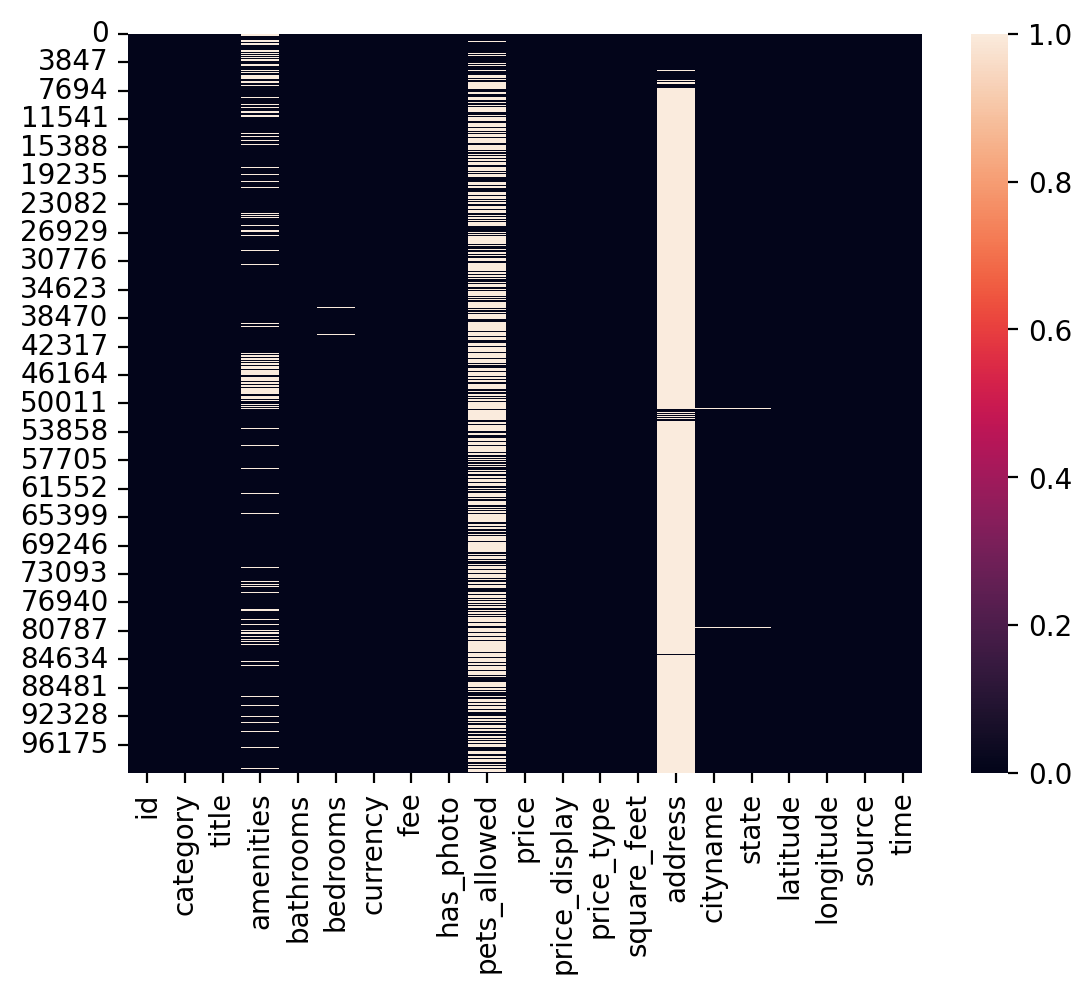

In [5]:
sns.heatmap(df_apartments.isna());

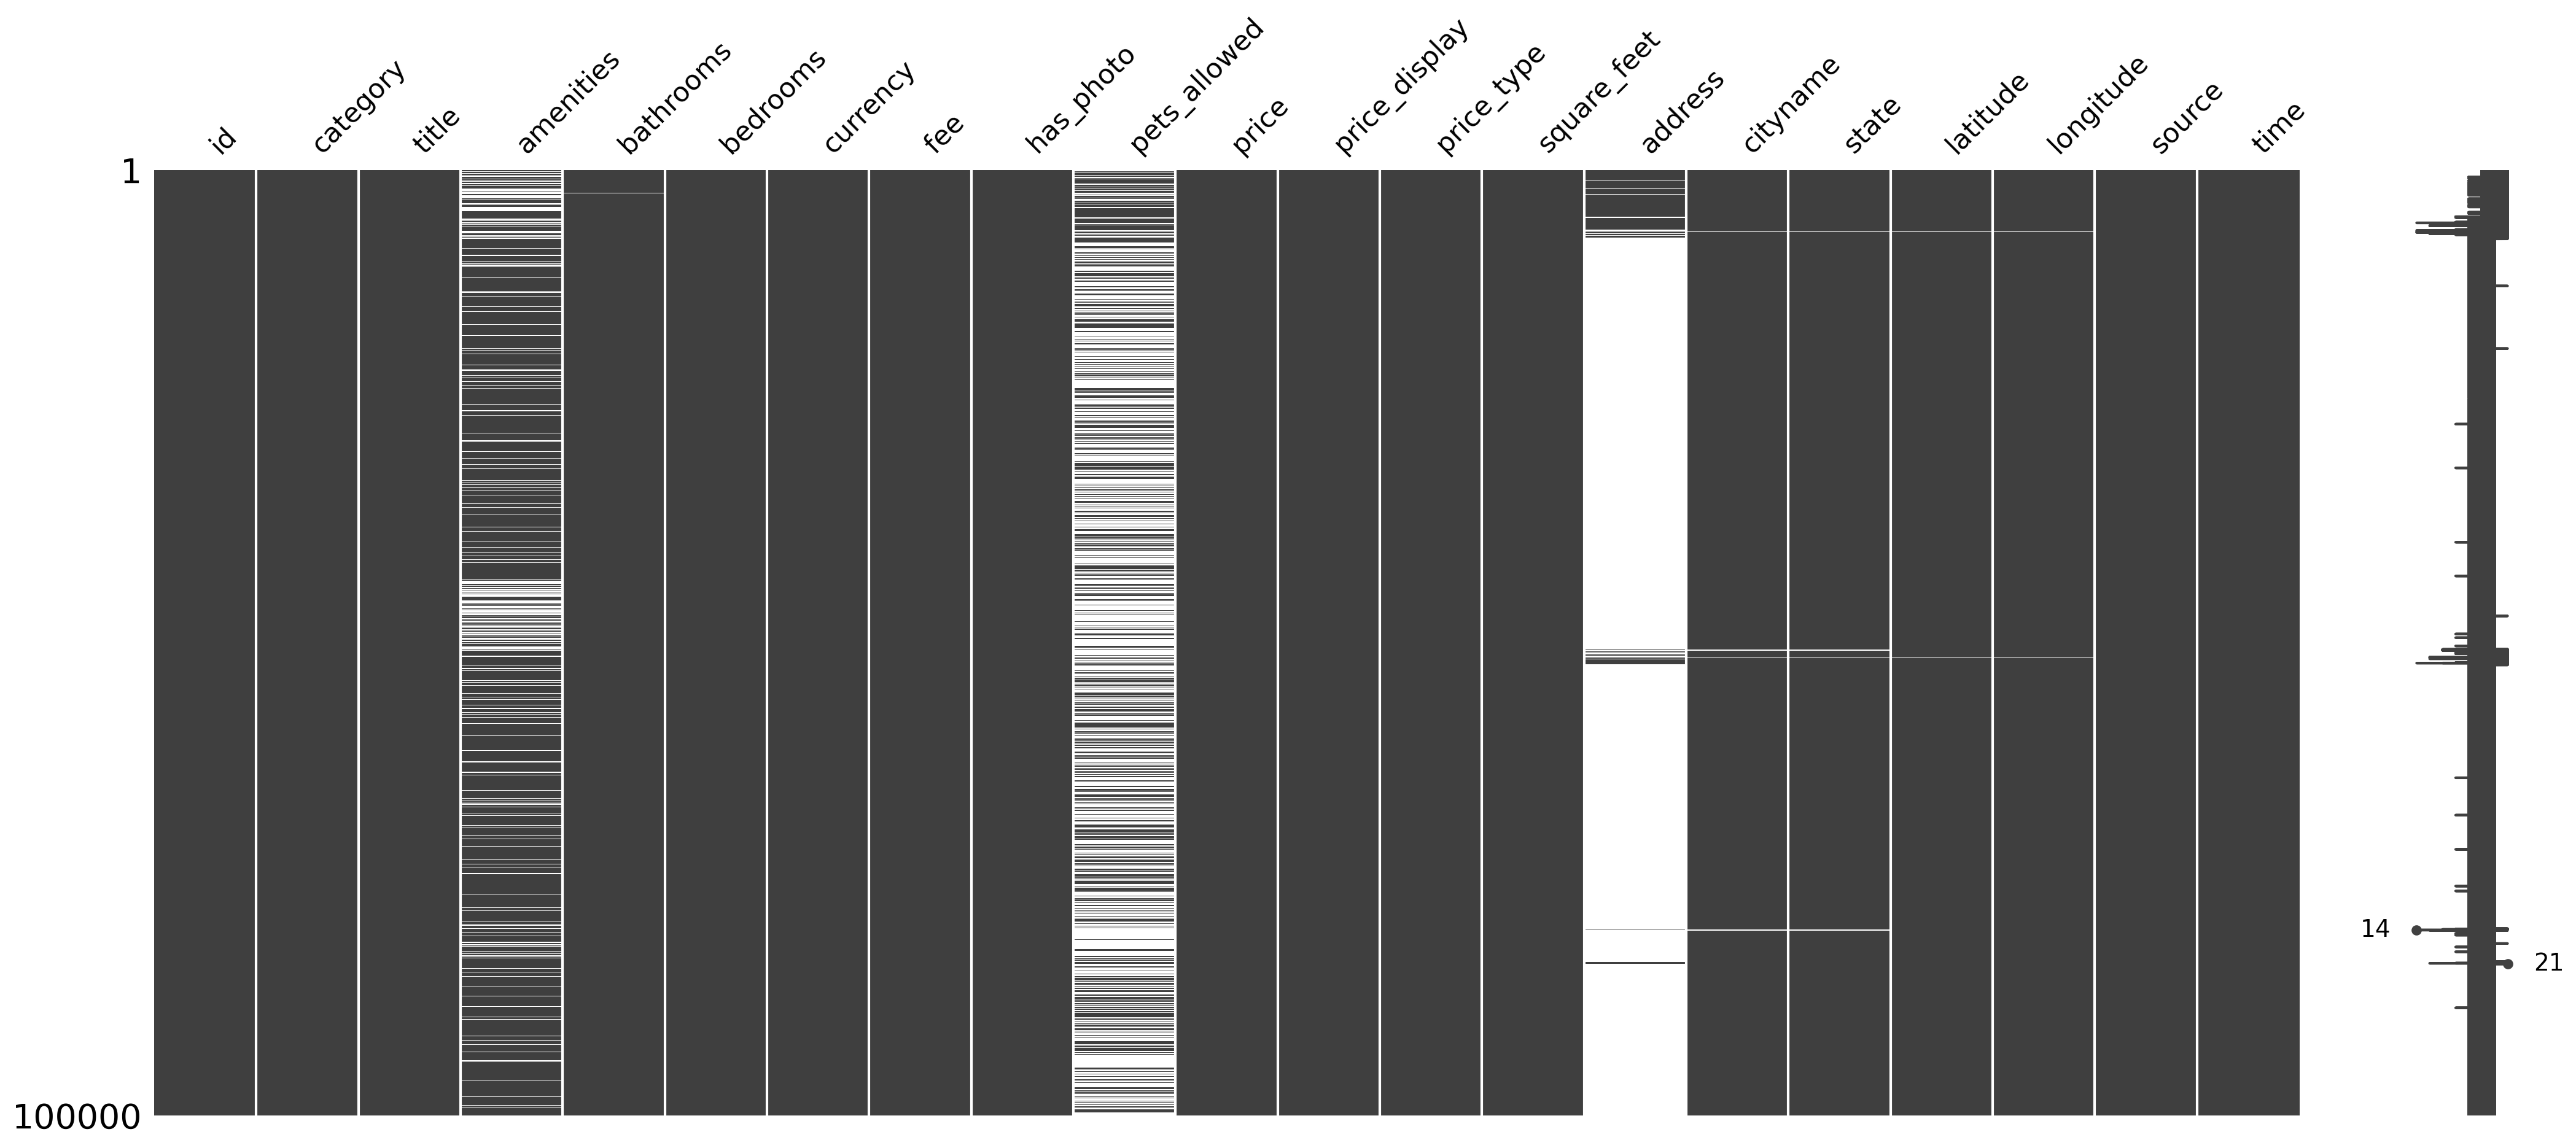

In [6]:
msno.matrix(df_apartments);

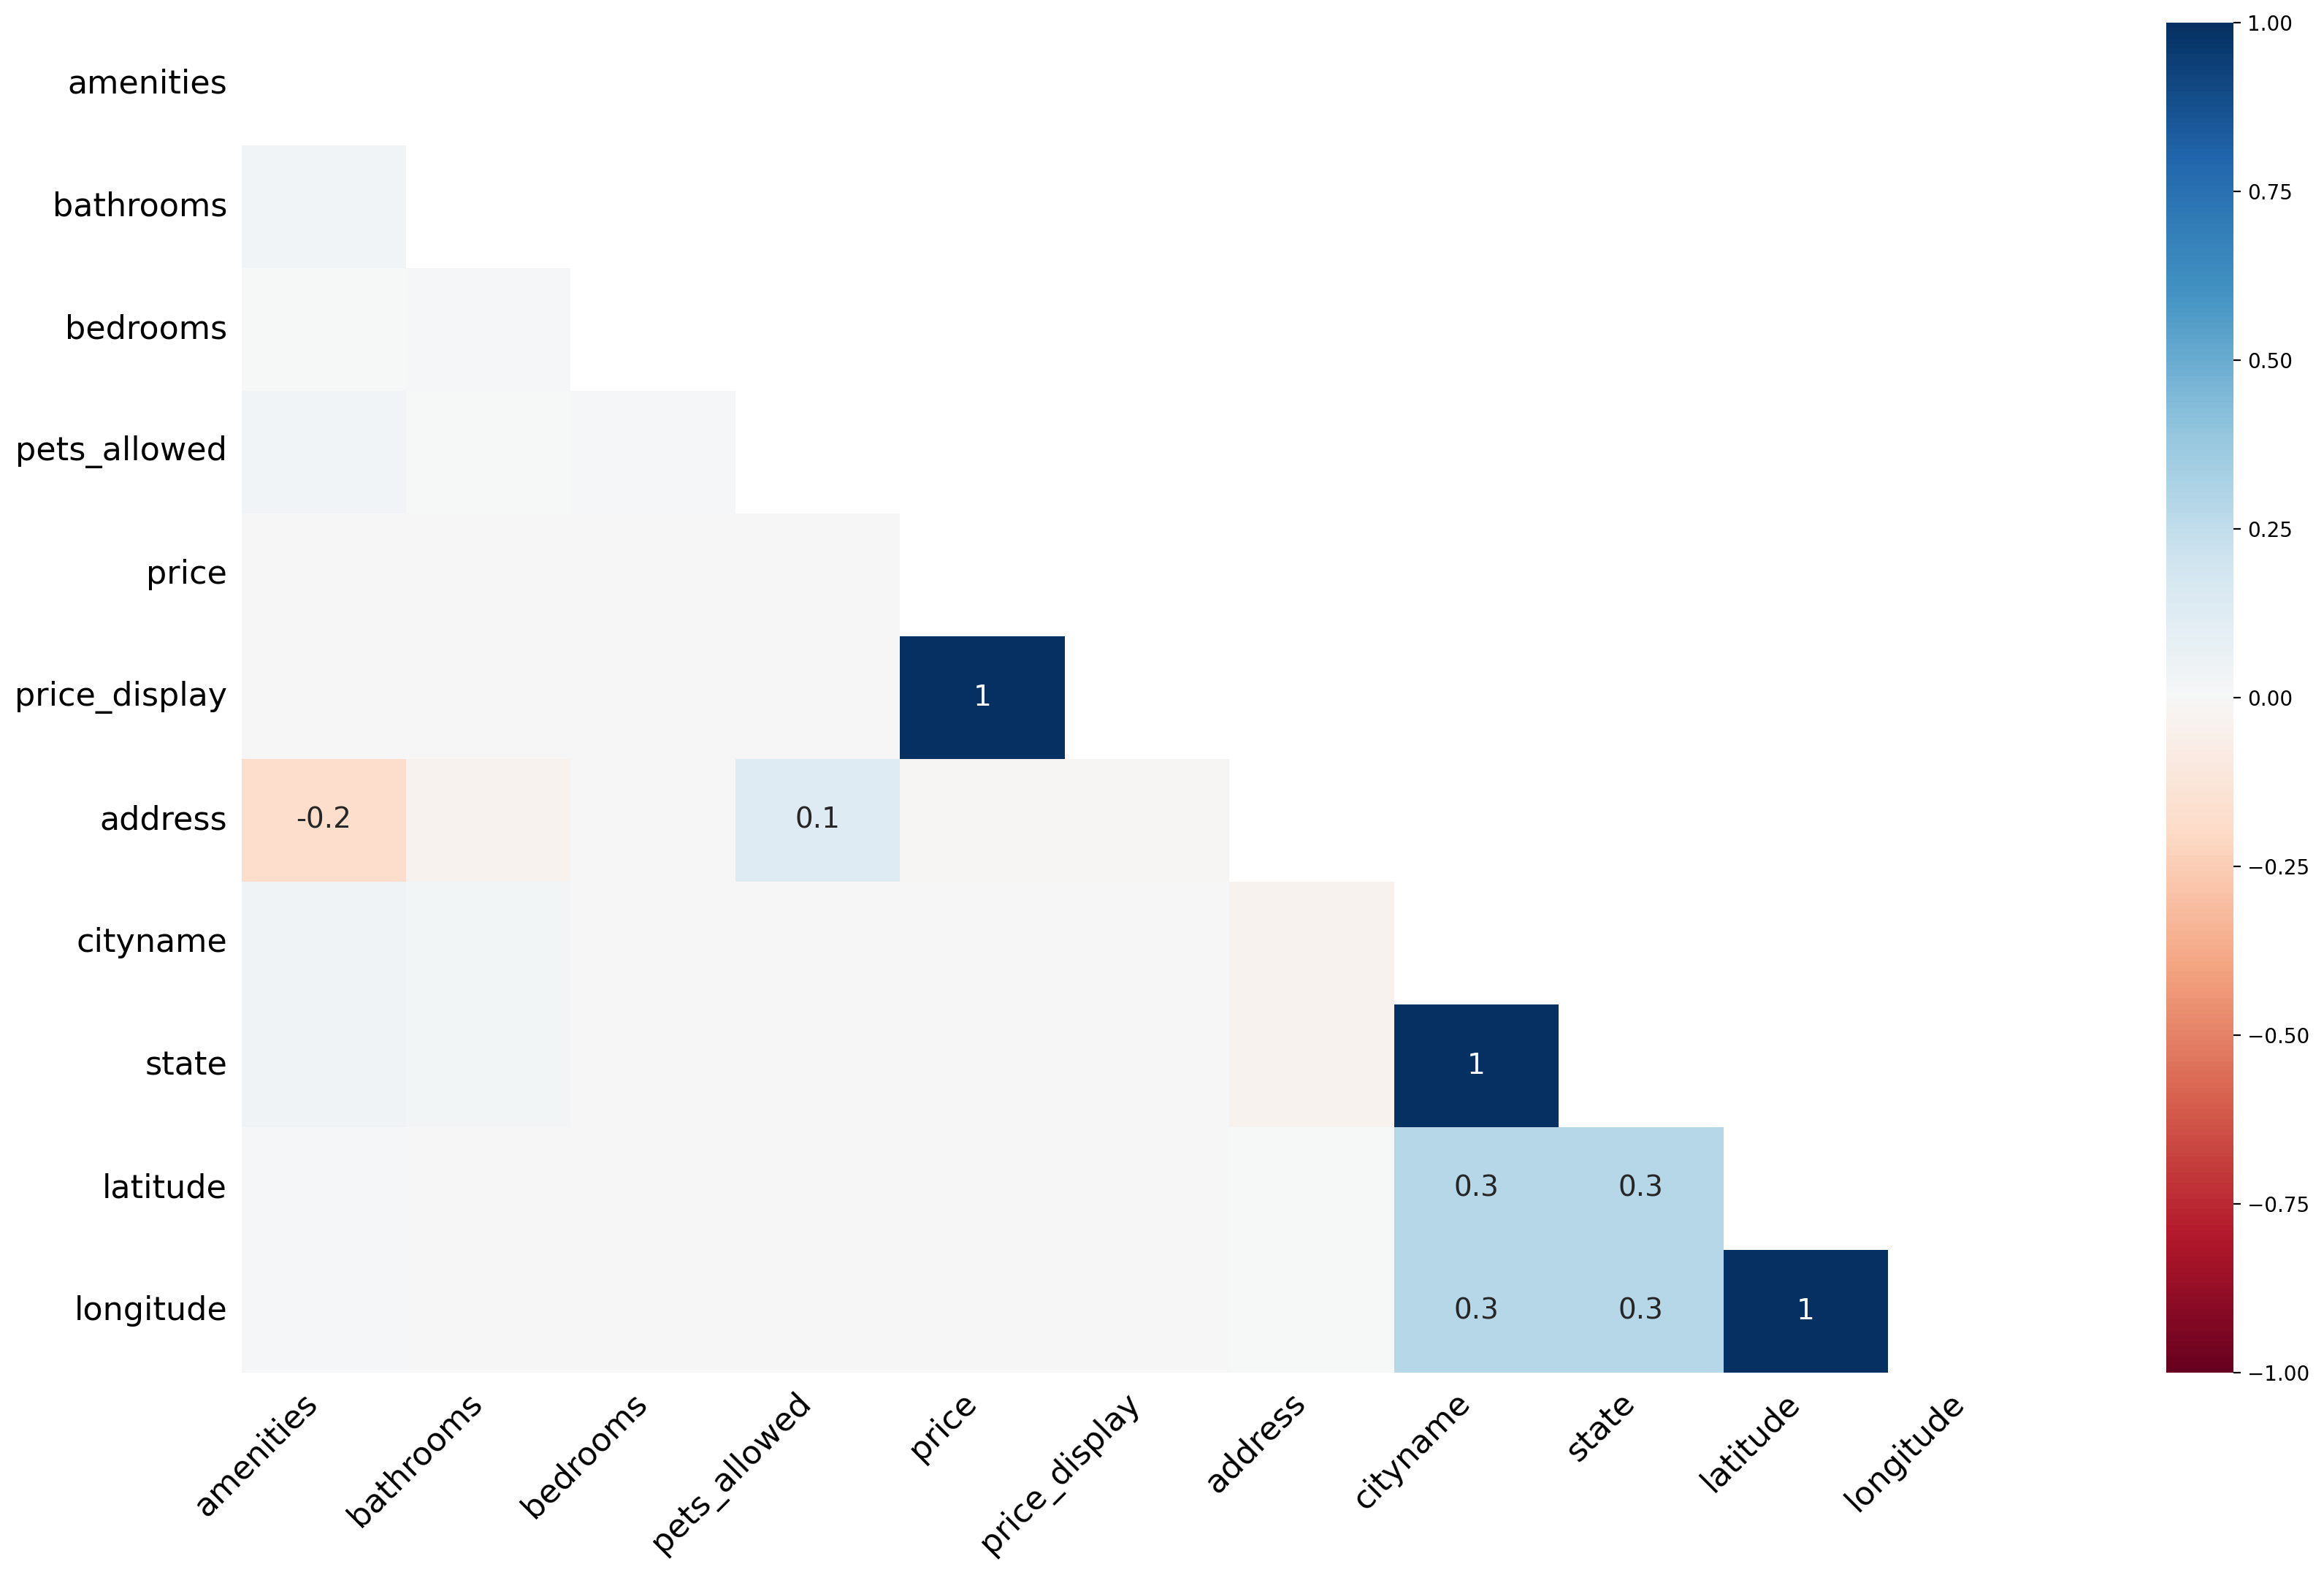

In [7]:
msno.heatmap(df_apartments);

#### Krótka analiza i modyfikacje
Widzimy, że brakujące dane są w kategoriach takich jak zwierzęta, pomieszczenia, adresy, nazwy miast, stany i współrzędne geograficzne.
Poniżej zrobiono zestawienie wyników i na ich bazie dokonano podziału na informacje do odrzucenia i ewentualnego uzupełnienia.

In [8]:
df_apartments.isnull().sum()

id                   0
category             0
title                0
amenities        16091
bathrooms           63
bedrooms           124
currency             0
fee                  0
has_photo            0
pets_allowed     60744
price                1
price_display        1
price_type           0
square_feet          0
address          92057
cityname           302
state              302
latitude            25
longitude           25
source               0
time                 0
dtype: int64

In [9]:
df_apartments['pets_allowed'].value_counts()

pets_allowed
Cats,Dogs         37279
Cats               1849
Dogs                127
Cats,Dogs,None        1
Name: count, dtype: int64

Uwaga
Z tego wynika, że brak danych (NA) dla kolumny pets należy potraktować jako not allowed, duplikuje się strwierdzenie "Cats, Dogs, None" należy to zmienić na pojedynczy wpis "Cats, Dogs"

In [10]:
# Zgodnie z powyższym dopisuję zmianę null na "None"
df_apartments["pets_allowed"] = df_apartments["pets_allowed"].fillna("None")

#zamiana pozycji jednostkowej Cats,Dogs,None na Cats,Dogs
df_apartments['pets_allowed'] = df_apartments['pets_allowed'].str.replace("Cats,Dogs,None", "Cats,Dogs", regex=False)
df_apartments['pets_allowed'].value_counts()

pets_allowed
None         60744
Cats,Dogs    37280
Cats          1849
Dogs           127
Name: count, dtype: int64

In [11]:
# Zgodnie ze wstępną analizą w analiza.ipynb usuwamy linię bez ceny
df_apartments = df_apartments.dropna(subset=["price"])


df_najdrozsze = df_apartments[(df_apartments["price"] >= 10000) ]
df_drogie = df_apartments[(df_apartments["price"] >=5000) & (df_apartments["price"] < 10000)]
df_srednie = df_apartments[(df_apartments["price"] >=600) & (df_apartments["price"] < 5000)]
df_tanie = df_apartments[(df_apartments["price"] <600) ]

In [12]:
df_apartments['amenities'].value_counts()

amenities
Parking                                                                                                                                       6210
Parking,Storage                                                                                                                               2119
Gym,Pool                                                                                                                                      1876
Pool                                                                                                                                          1490
Gym,Parking,Pool                                                                                                                              1195
                                                                                                                                              ... 
AC,Basketball,Cable or Satellite,Dishwasher,Gym,Internet Access,Parking,Patio/Deck,Playground,Pool,Refrigera

#### Kolumna "amnetities"
Istotnym problemem, który napotkaliśmy w trakcie analizy zebranych danych jest kolumna "Amnetities" czyli "udogodnienia". 
W związku z tym, że widocznie dane, którą są w tej kolumnie są opisowe, to 9851 pozycji występuję jako jeden ciąg znaków. W wielu przypadkach może wynikać to z tego, że niektórzy ogłaszający traktują udogodnienie jako coś dodatkowego, a inni właściciele uważajają coś za podstawową funkcję  (przykład: parking).

Z uwagi na to, rozbiliśmy kazdą komórkę w tej kolumnie oddzieloną przecinkiem na poszczególne udogodnienia, sprawdziliśmy ilość występujących udogodnień i na bazie tego i własnych odczuć zdefiniowaliśmy, które z zawartych w danych udogodnień można rzeczywiście uznać za udogodnienia, a które nie.

Zdeccydowaliśmy zbudować macierz binarną, która będzie zawierała wymienione udogodnienia i każdą z nich rozbije na oddzielną kolumnę, by następnie oznaczyć je jako występujące w danej obserwacji lub nie.

In [13]:
# Tworzymy dla każdego udogodnienia kolumnę 0-1 gdzie 0 to nie występuje, a 1 - występuje.
amenities_rozbite = df_apartments["amenities"].str.get_dummies(sep=',')
amenities_rozbite.sum()

AC                    15881
Alarm                   364
Basketball             4168
Cable or Satellite    12579
Clubhouse             19195
Dishwasher            16687
Doorman                 221
Elevator               4348
Fireplace             14986
Garbage Disposal       3899
Gated                  8687
Golf                     27
Gym                   37511
Hot Tub                4011
Internet Access       11127
Luxury                  211
Parking               44049
Patio/Deck            26650
Playground            11390
Pool                  43750
Refrigerator          14988
Storage               21731
TV                     4516
Tennis                 8542
View                   2101
Washer Dryer          26137
Wood Floors            8934
dtype: int64

#### 3.2. Modyfikacje danych

In [14]:
# 1. Połączenie oryginalnego DataFrame z nowo utworzonymi 
df_apartments = df_apartments.join(amenities_rozbite)

# Usunięcie starej, niesformatowanej kolumny tekstowej
df_apartments = df_apartments.drop(columns=['amenities'])

In [15]:
# Podglądamy listę ze wszystkimi kolumnami
print(df_apartments.columns.tolist())

# Podglądamy 5 pierwszych obserwacji
df_apartments.head(5)

['id', 'category', 'title', 'bathrooms', 'bedrooms', 'currency', 'fee', 'has_photo', 'pets_allowed', 'price', 'price_display', 'price_type', 'square_feet', 'address', 'cityname', 'state', 'latitude', 'longitude', 'source', 'time', 'AC', 'Alarm', 'Basketball', 'Cable or Satellite', 'Clubhouse', 'Dishwasher', 'Doorman', 'Elevator', 'Fireplace', 'Garbage Disposal', 'Gated', 'Golf', 'Gym', 'Hot Tub', 'Internet Access', 'Luxury', 'Parking', 'Patio/Deck', 'Playground', 'Pool', 'Refrigerator', 'Storage', 'TV', 'Tennis', 'View', 'Washer Dryer', 'Wood Floors']


,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,Patio/Deck,Playground,Pool,Refrigerator,Storage,TV,Tennis,View,Washer Dryer,Wood Floors
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,1.0,1.0,USD,No,Thumbnail,Cats,2195.0,...,0,0,0,0,0,0,0,0,0,0
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,1.5,3.0,USD,No,Thumbnail,"Cats,Dogs",1250.0,...,0,0,0,0,0,0,0,0,0,0
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,2.0,3.0,USD,No,Thumbnail,None,1395.0,...,0,0,0,0,0,0,0,0,0,0
3,5668639659,housing/rent/apartment,Two BR 209 Aegean Way,1.0,2.0,USD,No,Thumbnail,"Cats,Dogs",1600.0,...,0,0,0,0,0,0,0,0,0,0
4,5668639374,housing/rent/apartment,One BR 4805 Marquette NE,1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",975.0,...,0,0,0,0,0,0,0,0,0,0


W dalszym kroku sprawdzamy zgodnosc nazewnictwa stanów i miast, gdyż na dalszym etapie są ważne do statystyki cen.

In [16]:
# Filtrujemy wiersze, gdzie ZARÓWNO cityname JAK I state są puste
pokrycie_miast=df_apartments[df_apartments['cityname'].isnull() & df_apartments['state'].isnull()]
len(pokrycie_miast)

302

Wiemy juz, że mamy 302 brakujące informacje jednocześnie o stanie i o mieście, ale sprawdzamy, czy nie mamy w danych przypadkiem ich położenia geograficznego. Najpierw sprawdzmy zgodność szerokości i wysokośki, a dokładniej -  braku informacji o nich.

In [17]:
pokrycie=df_apartments[df_apartments['latitude'].isnull() & df_apartments['state'].isnull()]
len(pokrycie)

25

Mamy informację, że 25 miast mają nieznany stan i współrzędne goegraficzne, więc mamy 0 informacji o lokacji. Sprawdzamy dalej adres, jeśli wyjdzie więcej niż 0 oznacza to, że mamy dezinformację i wyniki należy odrzucić.

In [18]:
pokrycie_adresu=df_apartments[df_apartments['address'].isnull() & df_apartments['latitude'].isnull()]
len(pokrycie_adresu)

25

Mamy 25 cen nieruchomości bez żadnych informacji o lokalizacji.
Zdecydowaliśmy je usunąć, gdyż przy 100k rekordow to tylko 0,3% zbioru.

In [19]:
# Wyniki usuwamy
df_apartments = df_apartments.dropna(subset=['cityname'])
df_apartments.isnull().sum()

id                        0
category                  0
title                     0
bathrooms                59
bedrooms                124
currency                  0
fee                       0
has_photo                 0
pets_allowed              0
price                     0
price_display             0
price_type                0
square_feet               0
address               91827
cityname                  0
state                     0
latitude                  0
longitude                 0
source                    0
time                      0
AC                        0
Alarm                     0
Basketball                0
Cable or Satellite        0
Clubhouse                 0
Dishwasher                0
Doorman                   0
Elevator                  0
Fireplace                 0
Garbage Disposal          0
Gated                     0
Golf                      0
Gym                       0
Hot Tub                   0
Internet Access           0
Luxury              

Widzimy, że wstępnie udało pozbyć się braków w wartościach. Dołączamy analizę łazieniek  i sypialni.

Wyrywkowe sprawdzenie wierszy, dla których brakuje danych o łazience, pozwala na wysnucie wniosków iż, prawdopodobnie te łazienki występują. Jednakże nie ma pewności co do tego, bezpieczniejszą opcją jest usunięcie tych danych. 

In [20]:
df_apartments = df_apartments.dropna(subset=["bathrooms"])

Sprawdzono wyrywkowo w sieci linie, dla których przypisano 0 sypialni. </BR>
Wzięto pod uwagę, ze 500 ft² , to 46,45 m² h.</BR> w ofertach widnieją pomieszczenia bez sypialni mające 700 ft². Jednak 500 ft² jest liczbą bezpieczniejszą.</BR>
Pomieszczenia te podzielono na:
- nieduże pomieszczenia <span style="color: green;">square_feet < 500</span> łączące wiele funkcji typu:</BR>
    <span style="color: green;">kącik kuchenny + sypialny + TV</span></BR>
- większe pomieszczenia <span style="color: orange;">square_feet >= 500</span>, dla których błędnie nie przypasano sypialni, mimo, że w ofercie obecnie je widać </BR>
    Takich linii jest 90. Te dane bym usunęła

Podobną zasadę 500 ft² można użyć dla 125 linii, które mają nieokreśloną ilość sypialni.    

In [21]:
# 1. Zostawiamy tylko poprawne wiersze (metraż < 500 LUB sypialnie > 0 i nie-null)
df_apartments = df_apartments[(df_apartments["square_feet"] < 500) | (df_apartments["bedrooms"] > 0)]

# 2. Resztę braków (w małych mieszkaniach) zamieniamy na 0
df_apartments["bedrooms"] = df_apartments["bedrooms"].fillna(0)


In [22]:
# Sprawdazmy błędy w nazewnictwach miast
surowe_miasta = df_apartments['cityname'].nunique()
oczyszczone_miasta = df_apartments['cityname'].str.lower().str.strip().nunique()

print(f"przed czyszczeniem: {surowe_miasta}")
print(f"po czyszczeniu: {oczyszczone_miasta}")

przed czyszczeniem: 2978
po czyszczeniu: 2978


Nie ma błędów w nazewnictwie miast.

In [23]:
import difflib
#skorzystamy z wcześniej zauważonego podobieństwa i pełnego pokrycia miast ze stanami (zaufamy że są wypełnione dobrze)
for stan, sub_df in df_apartments.groupby('state'):
    # Tworzymy słownik z liczbą wystąpień każdego miasta w danym stanie
    counts = sub_df['cityname'].str.strip().str.title().value_counts().to_dict()
    unikalne_miasta = sorted(counts.keys())
    
    seen = set()
    for miasto in unikalne_miasta:
        dopasowania = difflib.get_close_matches(miasto, unikalne_miasta, n=3, cutoff=0.85)
        if len(dopasowania) > 1:
            klucz = tuple(sorted(dopasowania))
            if klucz not in seen:
                seen.add(klucz)
                
                # Formatujemy podgląd: Nazwa_Miasta (ile razy występuje)
                szczegoly = [f"{m} ({counts[m]}x)" for m in dopasowania]
                print(f"[{stan}] Kontekst ilościowy: {szczegoly}")

[CA] Kontekst ilościowy: ['Corona (24x)', 'Coronado (17x)']
[CA] Kontekst ilościowy: ['Los Alamitos (7x)', 'Los Altos (2x)']
[CA] Kontekst ilościowy: ['Santa Clara (32x)', 'Santa Clarita (1x)']
[GA] Kontekst ilościowy: ['Gainesville (3x)', 'Hinesville (3x)']
[MA] Kontekst ilościowy: ['Bedford (19x)', 'Medford (18x)']
[MA] Kontekst ilościowy: ['Boston (598x)', 'Boylston (2x)']
[MA] Kontekst ilościowy: ['East Bridgewater (1x)', 'West Bridgewater (1x)']
[MA] Kontekst ilościowy: ['North Dartmouth (6x)', 'South Dartmouth (3x)']
[MA] Kontekst ilościowy: ['North Weymouth (5x)', 'South Weymouth (75x)']
[MA] Kontekst ilościowy: ['South Dartmouth (3x)', 'South Yarmouth (2x)', 'North Dartmouth (6x)']
[MA] Kontekst ilościowy: ['South Yarmouth (2x)', 'South Dartmouth (3x)']
[NH] Kontekst ilościowy: ['Campton (1x)', 'Hampton (18x)']
[NJ] Kontekst ilościowy: ['Hightstown (15x)', 'Wrightstown (1x)']
[NY] Kontekst ilościowy: ['Bedford (1x)', 'Medford (1x)']
[OH] Kontekst ilościowy: ['Broadview Heights 

#### 3.3. Sprawdzanie wartości błędów liczbowych

In [24]:
# Wykluczona zostaje macierz binarna z widoku, wprowadza niepotrzebny zamęt a wiemy, że jest dobrze
invisable = df_apartments.columns[20:50].tolist()
# Wykluczenie konkretnych kolumn invisable
df_apartments.drop(columns=invisable).describe()

,id,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
count,9.932600e+04,99326.000000,99326.000000,99326.000000,99326.000000,99326.000000,99326.000000,9.932600e+04
mean,5.358290e+09,1.446791,1.731732,1524.951282,955.837465,36.942110,-91.530310,1.559664e+09
std,1.844624e+08,0.547201,0.745337,883.264762,360.899473,4.602576,15.824146,1.103748e+07
min,5.121046e+09,1.000000,0.000000,100.000000,107.000000,19.573800,-159.369800,1.544174e+09
25%,5.197949e+09,1.000000,1.000000,1014.000000,730.000000,33.746200,-104.807800,1.550832e+09
50%,5.508673e+09,1.000000,2.000000,1350.000000,900.000000,37.213900,-84.539400,1.568745e+09
75%,5.509007e+09,2.000000,2.000000,1795.000000,1116.000000,39.955900,-77.576700,1.568767e+09
max,5.669439e+09,9.000000,9.000000,40000.000000,11318.000000,64.833200,-68.778800,1.577391e+09


W analizowanym zbiorze nie występują niepoprawne wartości ujemne (z wyjątkiem współrzędnych geograficznych, gdzie są one naturalne). Widoczne są jednak bardzo wysokie wartości maksymalne oraz nielogiczne wartości minimane, szczególnie dla ceny oraz powierzchni, co sugeruje obecność silnych wartości odstających lub błędów grubych. W celu ich dokładnej identyfikacji i oceny dystrybucji danych względem centrum rozkładu (mediany) zastosowano wykresy pudełkowe (boxplots). Opierają się one na statystyce pozycyjnej (kwartylach i rozstępie międzykwartylowym), co pozwala na jednoznaczne wskazanie obserwacji odstających poza wąsami wykresu, niezależnie od skali i asymetrii rozkładu.

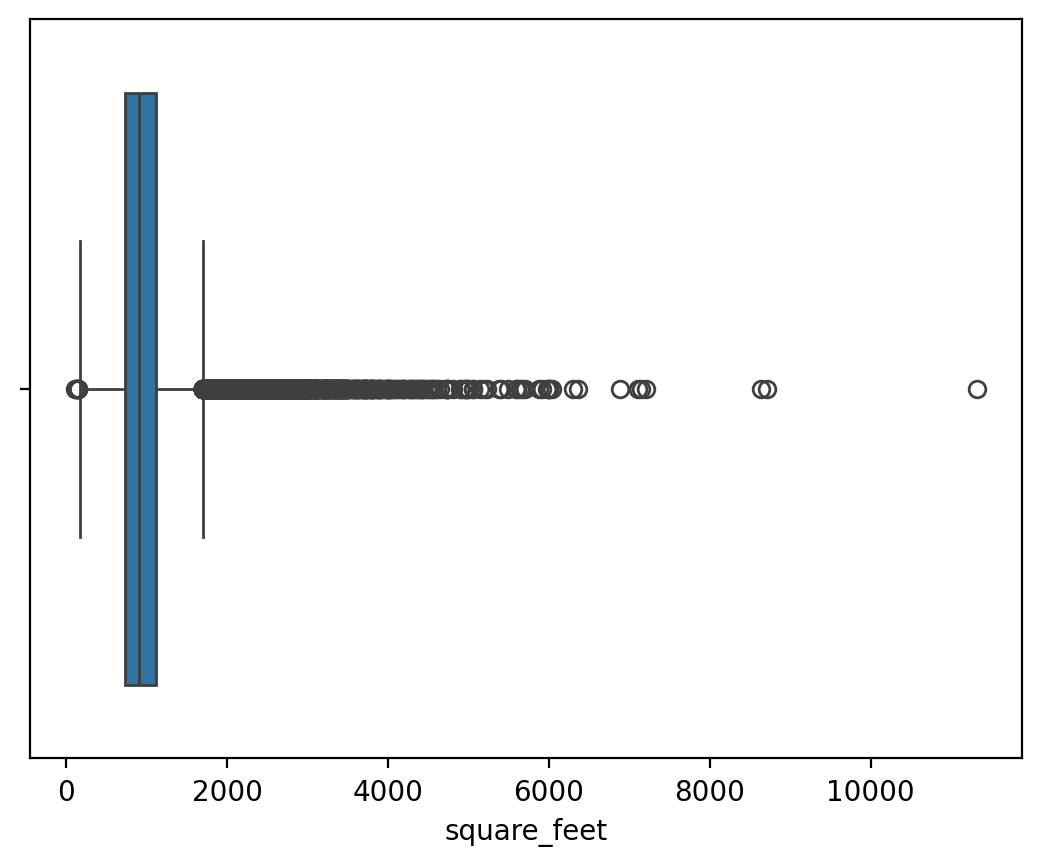

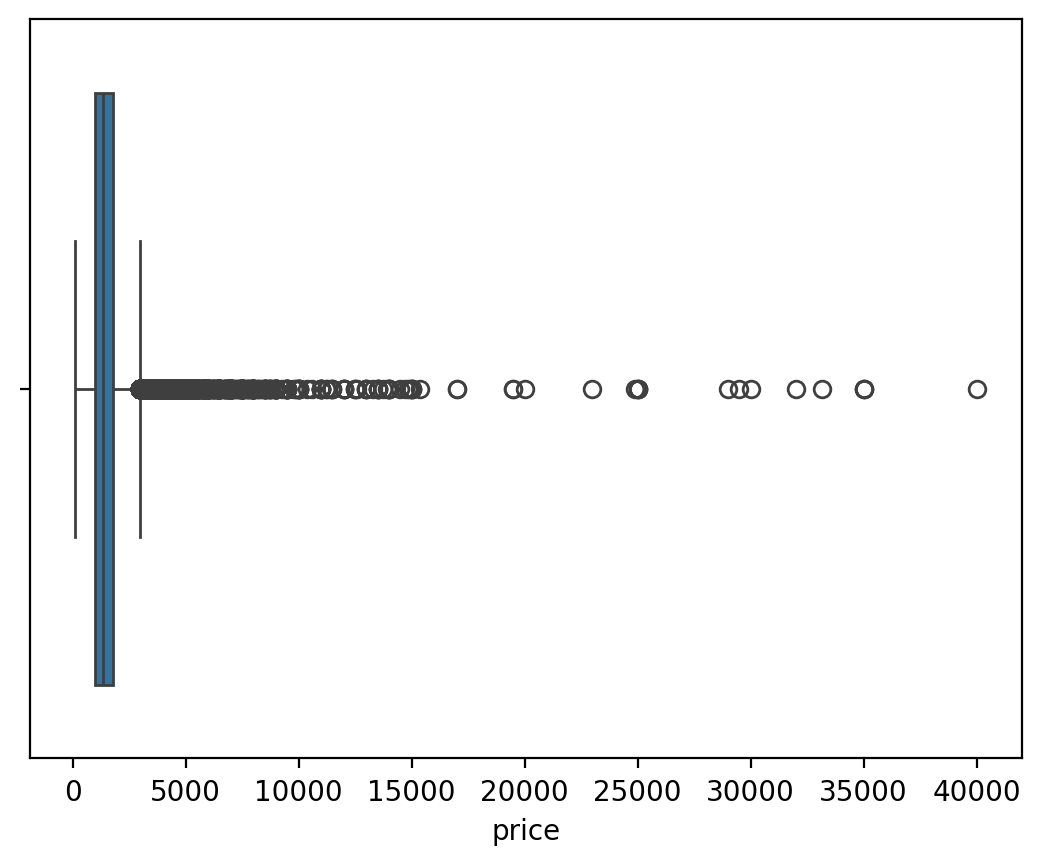

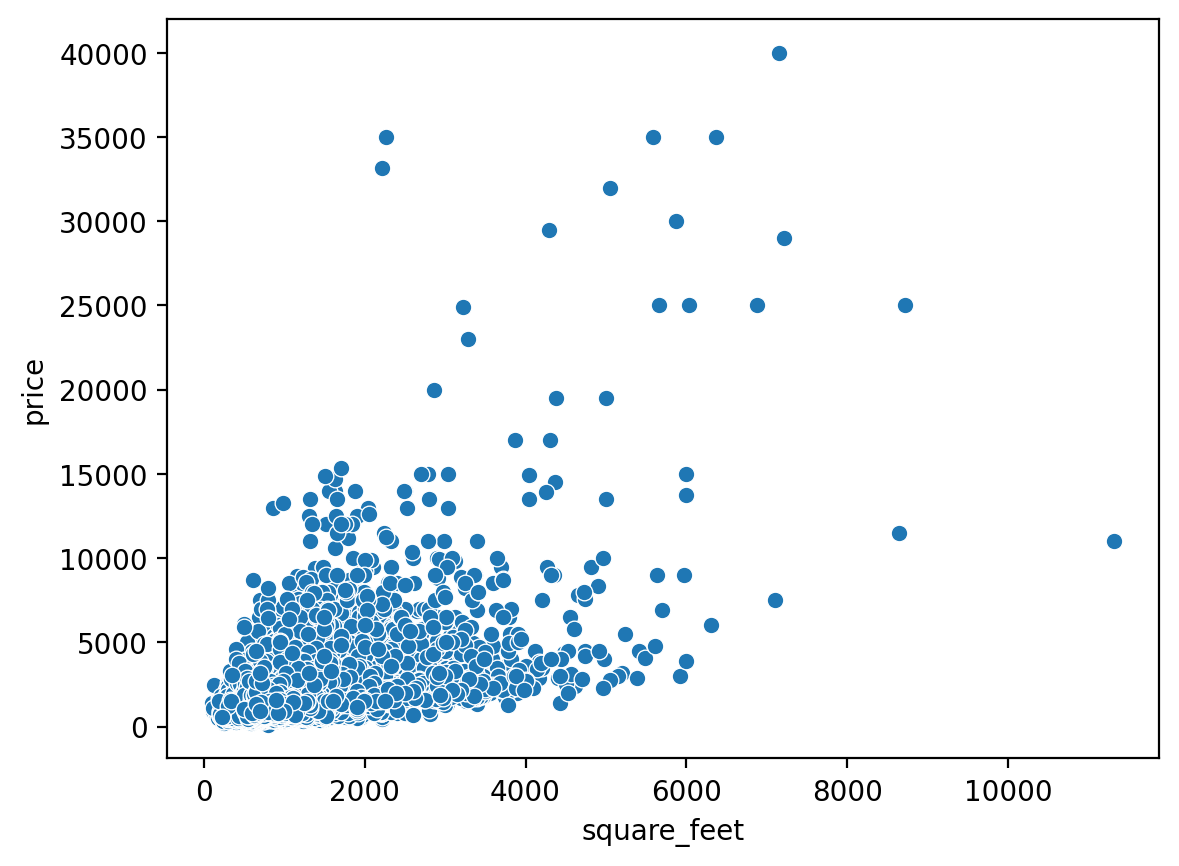

In [25]:
# Wykres dla ceny i metrażu
sns.boxplot(x=df_apartments['square_feet'])
py.show()
sns.boxplot(x=df_apartments['price'])
py.show()

# Wykres pokazujący relację ceny do metrażu
sns.scatterplot(x=df_apartments['square_feet'], y=df_apartments['price'])
py.show()

Na wykresach widać małe anomalnie, to te obszary najbardziej odległe od punktu zero osi. Sprawdzamy to jednak jeszcze w odniesieniu o parę innych zmiennych bądź też te bardzo bliskie 0.

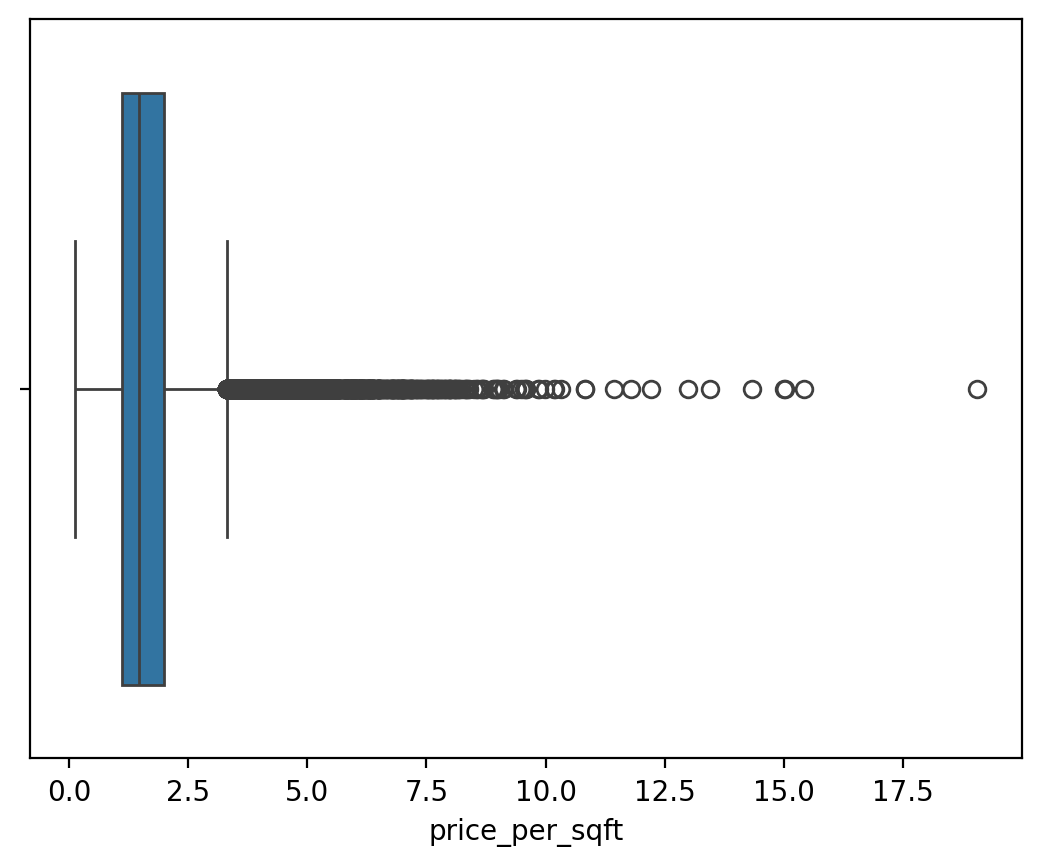

In [26]:
df_apartments['price_per_sqft'] = df_apartments['price'] / df_apartments['square_feet']
sns.boxplot(x=df_apartments['price_per_sqft'])
py.show()

In [27]:
# Podejrzany wydaje się być skrajny element na wykresie. Przyglądamy się 10 najbliższym anomaliom.
df_apartments['price'] 
df_apartments.sort_values(by='price', ascending=False).head(10)

,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,Playground,Pool,Refrigerator,Storage,TV,Tennis,View,Washer Dryer,Wood Floors,price_per_sqft
41358,5508880122,housing/rent/apartment,"Average Rent $40,000 a month - That's a STEAL!",8.0,6.0,USD,No,Yes,None,40000.0,...,0,1,0,0,0,1,0,0,0,5.598321
28170,5508903100,housing/rent/apartment,Pet Friendly 6+5 Apartment in West Hollywood,5.0,7.0,USD,No,No,None,35000.0,...,0,1,1,0,0,0,0,0,0,6.265664
41141,5508903015,housing/rent/apartment,"Stunning estate in the heart of /Sunset, just ...",7.5,6.0,USD,No,No,None,35000.0,...,0,1,0,0,0,0,0,0,0,5.497958
17206,5508899537,housing/rent/apartment,Four BR - ready to move in.,4.0,4.0,USD,No,Thumbnail,None,35000.0,...,0,0,0,0,0,0,0,0,0,15.425297
46243,5508991189,housing/rent/apartment,Apartment in great location. 2 Car Garage!,2.5,3.0,USD,No,Yes,None,33165.0,...,0,0,0,0,0,0,0,0,0,15.000000
38899,5508885857,housing/rent/apartment,"Average Rent $32,000 a month - That's a STEAL....",9.0,6.0,USD,No,Yes,None,32000.0,...,0,0,0,0,1,0,0,0,0,6.330366
14475,5509150943,housing/rent/apartment,This mountain contemporary is truly one of a k...,5.5,5.0,USD,No,Thumbnail,None,30000.0,...,0,0,0,0,0,0,1,1,0,5.108992
31412,5509006958,housing/rent/apartment,Three BR Apartment - Located in the heart of o...,3.0,3.0,USD,No,Yes,None,29500.0,...,0,0,0,0,0,0,1,0,0,6.874854
38802,5508917546,housing/rent/apartment,Sensational Tuscan Villa nestled in a cul-de-s...,6.0,6.0,USD,No,Yes,None,29000.0,...,0,1,0,0,0,0,1,0,0,4.020519
3487,5668640983,housing/rent/apartment,Six BR 256 Las Entradas,8.0,6.0,USD,No,Thumbnail,None,25000.0,...,0,0,0,0,0,0,0,0,0,2.868288


In [28]:
df_apartments['square_feet'] 

df_apartments.sort_values(by='square_feet', ascending=False).head(10)

,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,Playground,Pool,Refrigerator,Storage,TV,Tennis,View,Washer Dryer,Wood Floors,price_per_sqft
3907,5668643292,housing/rent/apartment,Six BR 9908 Bentcross Drive,8.5,6.0,USD,No,Thumbnail,None,11000.0,...,0,0,0,0,0,0,0,0,0,0.971903
3487,5668640983,housing/rent/apartment,Six BR 256 Las Entradas,8.0,6.0,USD,No,Thumbnail,None,25000.0,...,0,0,0,0,0,0,0,0,0,2.868288
96260,5121433095,housing/rent/apartment,Bedford - superb Apartment nearby fine dining,6.0,5.0,USD,No,Yes,None,11500.0,...,0,0,0,0,0,0,0,0,0,1.330557
38802,5508917546,housing/rent/apartment,Sensational Tuscan Villa nestled in a cul-de-s...,6.0,6.0,USD,No,Yes,None,29000.0,...,0,1,0,0,0,0,1,0,0,4.020519
41358,5508880122,housing/rent/apartment,"Average Rent $40,000 a month - That's a STEAL!",8.0,6.0,USD,No,Yes,None,40000.0,...,0,1,0,0,0,1,0,0,0,5.598321
79786,5197893701,housing/rent/apartment,Five BR Apartment - A model of grace & elegance.,5.5,5.0,USD,No,No,None,7500.0,...,0,0,0,0,0,0,0,0,0,1.055743
23678,5509021087,housing/rent/apartment,Four BR Apartment - Beautiful bluff top proper...,5.0,4.0,USD,No,Thumbnail,None,25000.0,...,0,0,0,0,0,0,0,0,0,3.633193
41141,5508903015,housing/rent/apartment,"Stunning estate in the heart of /Sunset, just ...",7.5,6.0,USD,No,No,None,35000.0,...,0,1,0,0,0,0,0,0,0,5.497958
7126,5630240092,housing/rent/apartment,Five BR 5407 Abbott Place - Abbott,4.0,5.0,USD,No,Thumbnail,None,6000.0,...,0,0,0,0,0,0,0,0,0,0.952381
41625,5508857852,housing/rent/apartment,"Bright Los Angeles, Five BR, Six BA for rent. ...",7.0,5.0,USD,No,Yes,None,25000.0,...,0,1,0,0,0,0,0,0,0,4.142502


In [29]:
df_apartments['price_per_sqft'] = df_apartments['price'] / df_apartments['square_feet']
df_apartments.sort_values(by='price_per_sqft', ascending=False).head(10)

,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,Playground,Pool,Refrigerator,Storage,TV,Tennis,View,Washer Dryer,Wood Floors,price_per_sqft
7148,5667891676,housing/rent/apartment,0 BR in New York NY 10019,1.0,0.0,USD,No,Thumbnail,None,2475.0,...,0,1,0,1,0,0,0,0,0,19.038462
17206,5508899537,housing/rent/apartment,Four BR - ready to move in.,4.0,4.0,USD,No,Thumbnail,None,35000.0,...,0,0,0,0,0,0,0,0,0,15.425297
37395,5508850926,housing/rent/apartment,Contemporary Executive Residence in wood.,2.0,2.0,USD,No,Yes,None,12995.0,...,0,0,0,0,0,0,0,0,0,15.023121
46243,5508991189,housing/rent/apartment,Apartment in great location. 2 Car Garage!,2.5,3.0,USD,No,Yes,None,33165.0,...,0,0,0,0,0,0,0,0,0,15.000000
45730,5508899890,housing/rent/apartment,Studio - heart of the Sunset Strip. Will Consi...,1.0,2.0,USD,No,Thumbnail,None,8700.0,...,0,1,0,0,0,0,0,0,0,14.332784
88550,5121223336,housing/rent/apartment,Apartment for rent in New York.,2.5,4.0,USD,No,Yes,None,13278.0,...,0,0,0,0,0,0,0,0,1,13.439271
4998,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...",1.0,0.0,USD,No,Thumbnail,None,1390.0,...,0,0,0,0,0,0,0,0,0,12.990654
97321,5121374579,housing/rent/apartment,Two BR Apartment - Located in Downtown tan s m...,2.0,2.0,USD,No,Yes,None,6100.0,...,0,0,0,0,0,0,0,0,0,12.200000
97322,5121374247,housing/rent/apartment,Two BR Apartment - Located in Downtown tan s m...,2.0,2.0,USD,No,Yes,None,5900.0,...,0,0,0,0,0,0,0,0,0,11.800000
89783,5121712250,housing/rent/apartment,Now offering 2 year lease with no increase!,2.0,2.0,USD,No,Yes,None,4611.0,...,0,0,0,0,1,0,0,0,1,11.441687


In [30]:
with pd.option_context('display.max_columns', None, 'display.expand_frame_repr', False):
    print(df_apartments[df_apartments['id'] == 5667891676])

              id                category                      title  bathrooms  bedrooms currency fee  has_photo pets_allowed   price price_display price_type  square_feet           address   cityname state  latitude  longitude    source        time  AC  Alarm  Basketball  Cable or Satellite  Clubhouse  Dishwasher  Doorman  Elevator  Fireplace  Garbage Disposal  Gated  Golf  Gym  Hot Tub  Internet Access  Luxury  Parking  Patio/Deck  Playground  Pool  Refrigerator  Storage  TV  Tennis  View  Washer Dryer  Wood Floors  price_per_sqft
7148  5667891676  housing/rent/apartment  0 BR in New York NY 10019        1.0       0.0      USD  No  Thumbnail         None  2475.0        $2,475    Monthly          130  350 West 50th St  Manhattan    NY   40.7629   -73.9885  Listanza  1577289784   0      0           0                   0          0           1        0         1          0                 0      0     0    0        0                0       0        0           1           0     1       

In [31]:
with pd.option_context('display.max_columns', None, 'display.expand_frame_repr', False):
    print(df_apartments[df_apartments['id'] == 5668626833])

              id                category                                              title  bathrooms  bedrooms currency fee  has_photo pets_allowed   price price_display price_type  square_feet address   cityname state  latitude  longitude     source        time  AC  Alarm  Basketball  Cable or Satellite  Clubhouse  Dishwasher  Doorman  Elevator  Fireplace  Garbage Disposal  Gated  Golf  Gym  Hot Tub  Internet Access  Luxury  Parking  Patio/Deck  Playground  Pool  Refrigerator  Storage  TV  Tennis  View  Washer Dryer  Wood Floors  price_per_sqft
4998  5668626833  housing/rent/apartment  Studio apartment N Scott St, 14th St N, Arling...        1.0       0.0      USD  No  Thumbnail         None  1390.0        $1,390    Monthly          107     NaN  Arlington    VA    38.891   -77.0816  RentLingo  1577359410   0      0           0                   0          0           0        0         0          0                 0      0     0    0        0                0       0        0       

Uwaga
Większość z lokali nosi znamiona wielopokojowych, dobrze wyposażonych bądź luksusowych, lecz dwa nie wpisujące się w te ramy zostały poddane analizie. 
Oba bronią się swoją lokalizacją, jeden z nich to centrum Nowego Jorku na Manhattanie, drugi z kolei znajduje się tuż nad rzeką Potomak, naprzeciwko Georgetown i kluczowych dzielnic rządowych oraz biznesowych Waszyngtonu.  

Informacje o błędzie można stanowczo odrzucić patrząc na lokalizacje lokali, cena wydaje się adekwatna
Jednakże w zbiorze segregowanych ceną znalazły się dwa wystąpienia nielogiczne o tytułach zawierających "That's a steal"Usunęliśy je i sprawdzamy występowanie w innych grupach oraz czy nie ma ich więcej.

In [32]:
ilosc_zartow = df_apartments['title'].str.contains(r'\baverage\b', case=False, na=False)
print(f"Liczba ogłoszeń z 'Average' w tytule: {ilosc_zartow.sum()}")
zarty = df_apartments[ilosc_zartow]
zarty[['id', 'title', 'price']].head(10)

Liczba ogłoszeń z 'Average' w tytule: 1663


,id,title,price
7359,5509148143,"Average Rent $1,289 a month - That's a STEAL. ...",1289.0
7368,5509113870,"Average Rent $2,155 a month - That's a STEAL. ...",2155.0
7533,5509211431,Average Rent $805 a month - That's a STEAL. Si...,805.0
7536,5509179979,"Average Rent $2,101 a month - That's a STEAL. ...",2101.0
7590,5509041005,"Average Rent $2,055 a month - That's a STEAL. ...",2055.0
7670,5508793264,"Average Rent $1,832 a month - That's a STEAL!",1832.0
7675,5508761131,"Average Rent $1,565 a month - That's a STEAL. ...",1565.0
7740,5509260352,Average Rent $675 a month - That's a STEAL!,675.0
7763,5509237189,"Average Rent $1,735 a month - That's a STEAL. ...",1735.0
7859,5509011092,"Average Rent $3,135 a month - That's a STEAL. ...",3135.0


In [33]:
# Usuwamy te zabawne wystąpienia w danych.
zarty_do_usuniecia_1 = df_apartments['title'].str.contains(r'\baverage\b', case=False, na=False)
df_apartments = df_apartments[~zarty_do_usuniecia_1]

Sprawdzamy biegun najnizszej najniższej ceny oraz spam. 
Poniżej można zauważyć pewne nieprawidłowości, lokacje z ponadnomatywną ilością sypialni za bardzo niską cene, należy przejrzeć ceny za sqft rosnocą od najniższej

In [34]:
#sprawdzenie wartości minimalnych
df_apartments['price'] 
df_apartments.sort_values(by='price', ascending=True).head(10)

,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,Playground,Pool,Refrigerator,Storage,TV,Tennis,View,Washer Dryer,Wood Floors,price_per_sqft
52249,5570188951,housing/rent/apartment,Park Management LLC,1.0,2.0,USD,Yes,Thumbnail,None,100.0,...,0,0,1,0,0,0,0,0,1,0.125000
6286,5664571561,housing/rent/apartment,One BR Ridge Road,1.0,1.0,USD,No,Thumbnail,None,200.0,...,0,0,0,0,0,0,0,0,0,0.800000
4417,5668626546,housing/rent/apartment,Studio apartment 116 N 2nd St,1.0,1.0,USD,No,Thumbnail,None,224.0,...,0,0,0,0,0,0,0,0,0,0.381601
22973,5508727124,housing/rent/apartment,Come home to Auburn Trace Apartments. $264/mo,1.0,1.0,USD,No,Yes,None,264.0,...,1,0,0,0,0,0,0,1,0,0.352000
84243,5121995967,housing/rent/apartment,Apartment for rent in Talladega. Pet OK!,1.0,1.0,USD,No,Yes,"Cats,Dogs",285.0,...,0,0,1,0,1,0,0,0,0,0.712500
3769,5668617931,housing/rent/apartment,One BR 1200 Mallard Drive,1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",288.0,...,1,0,1,0,0,0,0,0,0,0.375979
53014,5198522226,housing/rent/apartment,Columbus - 1bd/One BA 736sqft Apartment for re...,1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",299.0,...,0,0,1,0,0,0,0,1,0,0.406250
52016,5648710683,housing/rent/apartment,Delmain Apartments,1.0,0.0,USD,Yes,Thumbnail,None,300.0,...,0,0,1,0,0,0,0,0,0,1.224490
4562,5668620544,housing/rent/apartment,Studio apartment 4440 Gulfway Dr,1.0,2.0,USD,No,Thumbnail,None,300.0,...,0,0,1,0,0,0,0,0,0,0.750000
12649,5509036351,housing/rent/apartment,MODERN LUXURIOUS LIVING. $309/mo,1.0,1.0,USD,No,Thumbnail,None,309.0,...,0,1,0,1,0,0,0,1,0,0.411451


In [35]:
# 1. Wyznaczenie granic 
dolny_prog = df_apartments['price_per_sqft'].quantile(0.01)  
gorny_prog = 20 

# 2. Zastosowanie warunku
df_apartments = df_apartments[
    (df_apartments['price_per_sqft'] >= dolny_prog) & 
    (df_apartments['price_per_sqft'] <= gorny_prog)
]

# 3. Sprawdzenie
print(f"Sensowny zakres cenowy za sqft: od {dolny_prog:.2f}$ do {gorny_prog:.2f}$")

Sensowny zakres cenowy za sqft: od 0.63$ do 20.00$


In [36]:
# Prawdopodbny scam lub źle wpisana wartość lub wartość przedpłaty, posortowanie danych według ceny za sqft przyniosło skutek i obnazyło zadzwiająco niskie ceny za sqft. Proponowanym rozwiązaniem jest zastosowanie percentyli do segregacji danych.
df_apartments['price_per_sqft'] = df_apartments['price'] / df_apartments['square_feet']

df_apartments.sort_values(by='price_per_sqft', ascending=True).head(5)

,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,Playground,Pool,Refrigerator,Storage,TV,Tennis,View,Washer Dryer,Wood Floors,price_per_sqft
51179,5432644284,housing/rent/apartment,Discover the difference of Summertree. $757/mo,2.0,2.0,USD,No,Thumbnail,None,757.0,...,1,1,0,0,0,0,0,0,0,0.625620
56662,5198425537,housing/rent/apartment,$610/mo - must see to believe.,1.0,2.0,USD,No,Thumbnail,None,610.0,...,0,0,0,0,0,0,0,0,1,0.625641
69223,5198424751,housing/rent/apartment,The Best of the Best in the City of Newport Ne...,1.0,2.0,USD,No,Thumbnail,None,610.0,...,0,0,0,0,0,0,0,0,1,0.625641
76446,5197811293,housing/rent/apartment,Prominence Apartments Three BR Luxury Apartmen...,2.0,3.0,USD,No,Yes,"Cats,Dogs",910.0,...,0,0,0,0,0,0,0,0,0,0.626290
65879,5198320257,housing/rent/apartment,"2nd Floor Two BR, One BA apartment home locate...",1.0,2.0,USD,No,Thumbnail,"Cats,Dogs",595.0,...,0,0,0,0,0,0,0,0,0,0.626316


Dla pewności wyników i analiz sprawdzamy też drugą stronę medalu - wartości maksymalne, które zostały odrzucone. Dane, jakie zostały pokazane przy percentylu 0,9 są zbyt okrojone, utraciliśmy znaczną część posiadłości luksusowych, wartość należy ustawić na stała np na poziomie najdroższego apartamentu lub pozostawić górną granice otwartą. 

In [37]:
# Wyświetlenie próby rekordów, które zostały odcięte jako "zbyt drogie" za sqft
anomalie_gorne = df_apartments[df_apartments['price_per_sqft'] > gorny_prog]
anomalie_gorne.sort_values(by='price_per_sqft', ascending=False)[['title', 'price', 'square_feet', 'price_per_sqft', 'cityname']].head(10)

,title,price,square_feet,price_per_sqft,cityname


In [38]:
#Kolejnym etapem jest sprawdzenie kolumn nie tak bardzo kluczowych ale jednak wystepujacych i mogących miec zanczenie są to kolumny "price_type, currency, fee"
# Sprawdzenie typów płatności 
print(df_apartments['price_type'].value_counts())

# Sprawdzenie unikalnych walut 
print(df_apartments['currency'].value_counts())

# Sprawdzenie prowizji (fee)
print(df_apartments['fee'].value_counts())

price_type
Monthly    96684
Weekly         2
Name: count, dtype: int64
currency
USD    96686
Name: count, dtype: int64
fee
No     96495
Yes      191
Name: count, dtype: int64


In [39]:
# Dla prostoty analizy posłużymy się tylko ofertami bez prowizji i z płatnościami wyłącznie co miesiąc
# Zostawiamy tylko te rekordy, które mają typ ceny "Monthly" i ofertę no Fee
df_apartments = df_apartments[(df_apartments['price_type'] == 'Monthly') & (df_apartments['fee'] == 'No')]

In [40]:
# W powyższej tabeli widzimy że pojawia się w kolumnie has_photo wartość "thumbnail"

thumbnail_count = (df_apartments['has_photo'] ).value_counts()
print(f"Liczba 'Thumbnail': {thumbnail_count}")

Liczba 'Thumbnail': has_photo
Yes          54395
Thumbnail    33148
No            8950
Name: count, dtype: int64


Widać tu że thumbnail występuję dość często, nie może być to bład, trzeba sprawdzić nomenklaturę. Po sprawdzeniu okazuję się, że to miniaturowe zdjęcie taka mała etykieta. Dla ułatwienia analizy zmienimy thumbnail na yes

In [41]:
df_apartments['has_photo'] = df_apartments['has_photo'].replace({'Thumbnail': 'Yes'})

In [42]:
# Ostatnim etapem jest sprawdzenie kategorii wynajmy czy aby napewno się zgadzają oraz sprawdzenie pod kątem występowania duplikatów

# Sprawdzenie kategorii
print(df_apartments['category'].value_counts())

# Zostawiamy wyłącznie apartamenty
df_apartments = df_apartments [df_apartments['category'] == 'housing/rent/apartment' ]
# Usuwamy duplikaty
df_apartments = df_apartments.drop_duplicates(subset=['title', 'price', 'square_feet', 'cityname', 'state'], keep='first')

category
housing/rent/apartment            96436
housing/rent/commercial/retail       42
housing/rent                          6
housing/rent/home                     4
housing/rent/short_term               2
housing/rent/condo                    2
housing/rent/other                    1
Name: count, dtype: int64


In [43]:
# 1. Przypisanie wyczyszczonej ramki danych
apartments_clean = df_apartments

# 2. Zapis do pliku CSV w folderze data/
sciezka_zapisu = "data/apartments_clean.csv"

## <span style="color:deepskyblue;">3. Wizualizacja danych i analiza opisowa</span>

Analiza dotycząca oferowanych powierzchni nieruchomości w ujęciu geograficznym


#### <span style="color: deepskyblue;">Wczytanie i modyfikacje  </span>



In [88]:
# Wczytujemy czysty plik
%matplotlib inline 
%config InlineBackend.figure_format = 'retina'

df = pd.read_csv("data/apartments_clean.csv", sep=';', encoding="cp1250")
df.head(5)

C:\Users\mhi\AppData\Local\Temp\ipykernel_30900\1559002404.py:5: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/apartments_clean.csv", sep=';', encoding="cp1250")


,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,Playground,Pool,Refrigerator,Storage,TV,Tennis,View,Washer Dryer,Wood Floors,price_per_sqft
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,1.0,1.0,USD,No,Yes,Cats,2195.0,...,0,0,0,0,0,0,0,0,0,4.049815
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,1.5,3.0,USD,No,Yes,"Cats,Dogs",1250.0,...,0,0,0,0,0,0,0,0,0,0.833333
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,2.0,3.0,USD,No,Yes,NaN,1395.0,...,0,0,0,0,0,0,0,0,0,0.845455
3,5668639659,housing/rent/apartment,Two BR 209 Aegean Way,1.0,2.0,USD,No,Yes,"Cats,Dogs",1600.0,...,0,0,0,0,0,0,0,0,0,1.951220
4,5668639374,housing/rent/apartment,One BR 4805 Marquette NE,1.0,1.0,USD,No,Yes,"Cats,Dogs",975.0,...,0,0,0,0,0,0,0,0,0,1.562500


In [89]:
df_state = pd.read_csv("data/przypisanie_stanowUSA.csv", sep=';', encoding="cp1250")
df_state.head(3)

,Stan,Skrot,Region,Strefa czasowa,Stan rolniczy,Stan przemyslowy,Wazny turystycznie
0,Alabama,AL,South,CST / EST,Tak,Tak,Nie
1,Alaska,AK,West,AKST / PST,Nie,Nie,Tak
2,Arizona,AZ,West,MST,Nie,Tak,Tak


In [90]:

# dołącz nazwę stanu
df = df.merge(
    df_state[['Skrot', 'Stan']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz region
df = df.merge(
    df_state[['Skrot', 'Region']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz Strefa czasowa
df = df.merge(
    df_state[['Skrot', 'Strefa czasowa']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz Stan rolniczy
df = df.merge(
    df_state[['Skrot', 'Stan rolniczy']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz Stan przemyslowy
df = df.merge(
    df_state[['Skrot', 'Stan przemyslowy']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')

# dołącz Wazny turystycznie
df = df.merge(
    df_state[['Skrot', 'Wazny turystycznie']],
    left_on='state',
    right_on='Skrot',
    how='left'
)
# usuń pomocniczą kolumnę
df = df.drop(columns='Skrot')
df.head(2)


,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,View,Washer Dryer,Wood Floors,price_per_sqft,Stan,Region,Strefa czasowa,Stan rolniczy,Stan przemyslowy,Wazny turystycznie
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,1.0,1.0,USD,No,Yes,Cats,2195.0,...,0,0,0,4.049815,California,West,PST,Tak,Tak,Tak
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,1.5,3.0,USD,No,Yes,"Cats,Dogs",1250.0,...,0,0,0,0.833333,Virginia,South,EST,Nie,Tak,Tak


In [91]:
# na podstawie pól logicznych określam charakter stanu
df['charakter'] = (
    np.where(df['Stan rolniczy']=="Tak", 'Roln ', '') +
    np.where(df['Stan przemyslowy']=="Tak", 'Przem ', '') +
    np.where(df['Wazny turystycznie']=="Tak", 'Turyst', '')
)

df['charakter'] = df['charakter'].str.strip()

df.head(5)

,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,Washer Dryer,Wood Floors,price_per_sqft,Stan,Region,Strefa czasowa,Stan rolniczy,Stan przemyslowy,Wazny turystycznie,charakter
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,1.0,1.0,USD,No,Yes,Cats,2195.0,...,0,0,4.049815,California,West,PST,Tak,Tak,Tak,Roln Przem Turyst
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,1.5,3.0,USD,No,Yes,"Cats,Dogs",1250.0,...,0,0,0.833333,Virginia,South,EST,Nie,Tak,Tak,Przem Turyst
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,2.0,3.0,USD,No,Yes,NaN,1395.0,...,0,0,0.845455,North Carolina,South,EST,Tak,Tak,Tak,Roln Przem Turyst
3,5668639659,housing/rent/apartment,Two BR 209 Aegean Way,1.0,2.0,USD,No,Yes,"Cats,Dogs",1600.0,...,0,0,1.951220,California,West,PST,Tak,Tak,Tak,Roln Przem Turyst
4,5668639374,housing/rent/apartment,One BR 4805 Marquette NE,1.0,1.0,USD,No,Yes,"Cats,Dogs",975.0,...,0,0,1.562500,New Mexico,West,MST,Nie,Nie,Tak,Turyst


In [92]:
df1 = df[(df["square_feet"] <= 300)]
df1["bin_square_feet"] = pd.cut(
    df1["square_feet"],
    bins=[0, 200, 250, 300, float("inf")],
    labels=["0-200", "200-250", "250-300", "300+"]
)
#df1.head(3)
#df1.to_csv('D:\\tmp\\df1.csv', sep=';', index=False, encoding='utf-8')

C:\Users\mhi\AppData\Local\Temp\ipykernel_30900\1388438337.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["bin_square_feet"] = pd.cut(


In [93]:
df2 = df[(df["square_feet"] > 300) & ( df["square_feet"] <= 2100) ]
df2["bin_square_feet"] = pd.cut(
    df2["square_feet"],
    bins=[300,500, 700, 1000, 1500, 2000, 2100, float("inf")],
    labels=["do 500", " do 700", " do 1000", "do 1500",
            " do 2000","do 2100", "2100+"]
)
#df2.head(3)

C:\Users\mhi\AppData\Local\Temp\ipykernel_30900\1251662969.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["bin_square_feet"] = pd.cut(


In [94]:
df3 = df[(df["square_feet"] > 2100)]
df3["bin_square_feet"] = pd.cut(
    df3["square_feet"],
    bins=[2100,2500,3000, 4000, 5000, 10000, float("inf")],
    labels=["do 2500", " do 3000", " do 4000", "do 5000","do 10000", "10000+"]
)
#df3.head(3)

C:\Users\mhi\AppData\Local\Temp\ipykernel_30900\2301134814.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["bin_square_feet"] = pd.cut(


In [95]:
df["bin_square_feet"] = pd.cut(
    df["square_feet"],
    bins=[300, 500, 700, 1000, 1500, 2000, 2500, float("inf")],
    labels=["0-300", "300-500", "500-700", "700-1000", "1000-1500","1500-2000","2000-2500"]
)
df.head(2)

,id,category,title,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,...,Wood Floors,price_per_sqft,Stan,Region,Strefa czasowa,Stan rolniczy,Stan przemyslowy,Wazny turystycznie,charakter,bin_square_feet
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,1.0,1.0,USD,No,Yes,Cats,2195.0,...,0,4.049815,California,West,PST,Tak,Tak,Tak,Roln Przem Turyst,300-500
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,1.5,3.0,USD,No,Yes,"Cats,Dogs",1250.0,...,0,0.833333,Virginia,South,EST,Nie,Tak,Tak,Przem Turyst,700-1000


#### <span style="color: deepskyblue;">Rozkład wartości powierzchni według Regionu USA dla różnych grup nieruchomości  </span>



In [96]:
# Wykres na którym na osi x będzie charakter, na osi y przedział_powierzchni, 
# kolorem określony stan, a wielkość kropki ma obrazować ilość linii w pliku odpowiadających kropce.

pio.renderers.default = "vscode"
# zliczenie rekordów dla każdej kombinacji
agg = (
    df.groupby(
        ["charakter", "bin_square_feet", "Region"]
    )
    .size()
    .reset_index(name="liczba")
)

#print(agg.head())

# wykres

region_colors = {
    "Northeast": "green",
    "Midwest": "yellow",
    "South": "orange",
    "West": "lightgreen"
}
charakter_colors = {
    "Roln": "green",
    "Roln Przem": "darkolivegreen",
    "Roln Przem Turyst": "lightgreen",
    "Roln Turyst": "darkgoldenrod",
    "Przem":"brown",
    "Przem Turyst": "darkorange",
    "Turyst": "yellow",
    "": "skyblue"
}
fig = px.scatter(
    agg,
    x="charakter",
    y="bin_square_feet",
    color="Region",
    color_discrete_map=region_colors,
    size="liczba",
    size_max=60,
    hover_data=["liczba"],
    labels={
        "charakter": "Charakter regionu",
        "bin_square_feet": "Przedział powierzchni (stóp²)"
    },
    title="Liczba ofert wg charakteru, przedziału powierzchni i Regionu USA"
)

#fig.update_layout(
#    width=1200,
#    height=800
#)

fig.show()


C:\Users\mhi\AppData\Local\Temp\ipykernel_30900\3652350368.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


Uszczegółowienie powyższego wykresu dla grup ofert o powierzchni małej, sredniej i dużej.

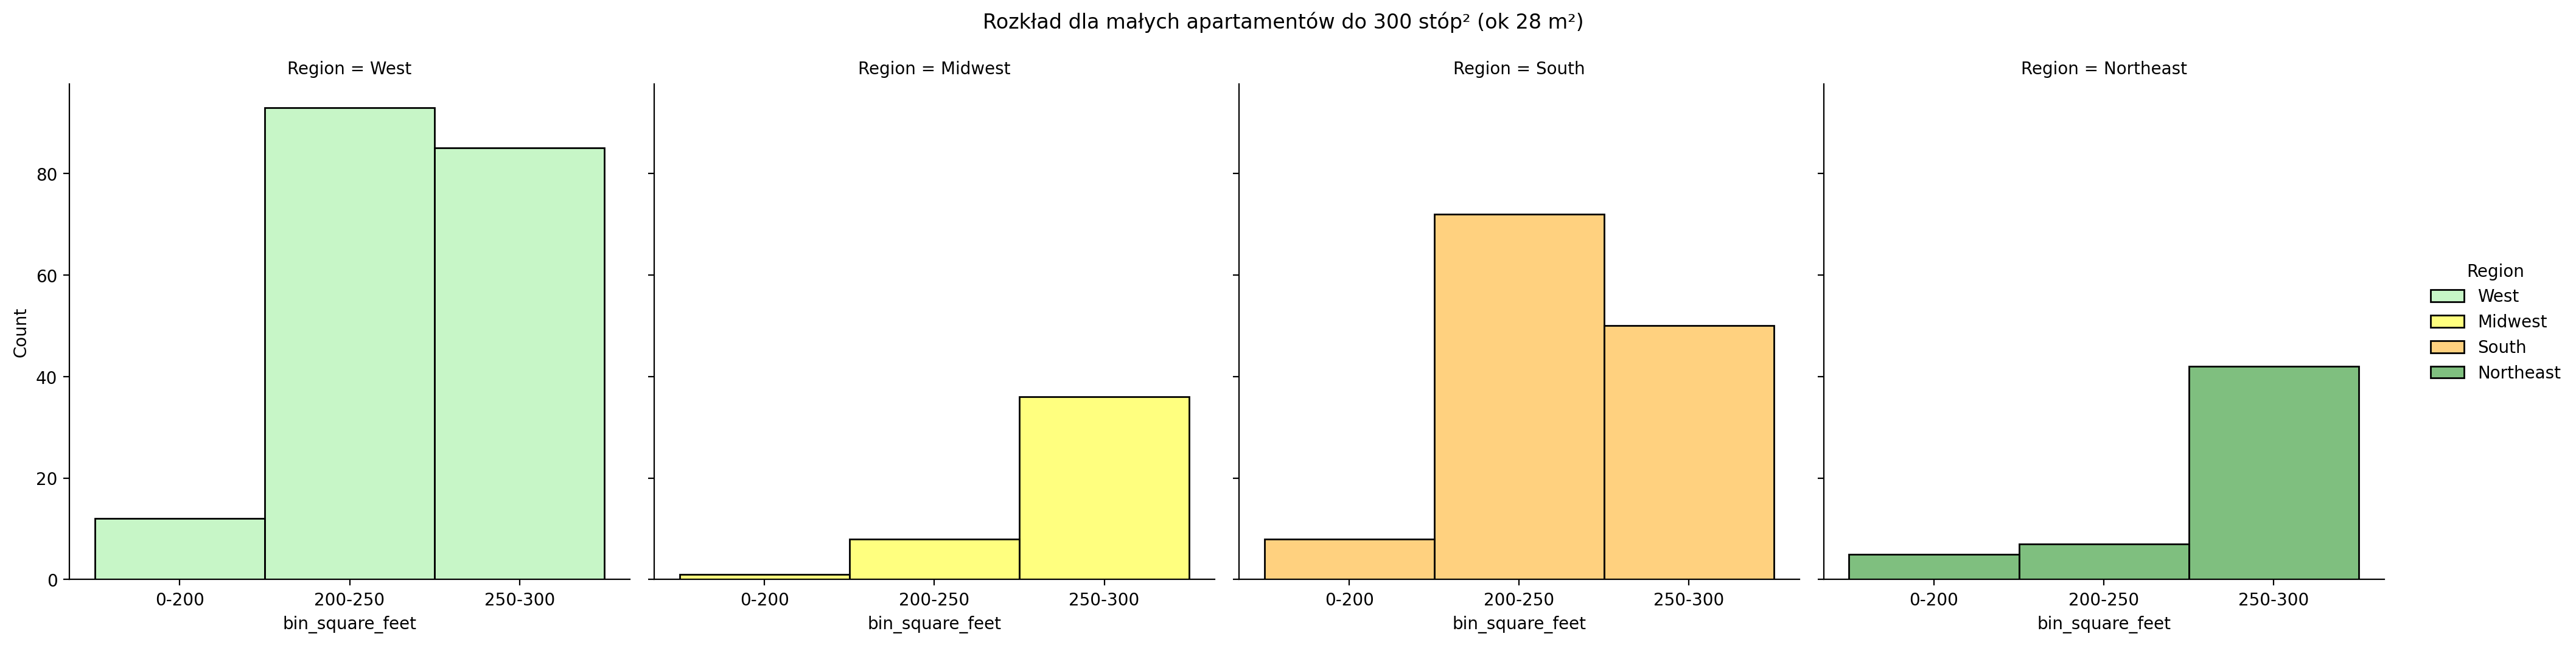

In [97]:
sns.displot(
    data=df1,
    x="bin_square_feet",
    col="Region",
    hue="Region",
    palette=region_colors
    
)
plt.suptitle("Rozkład dla małych apartamentów do 300 stóp² (ok 28 m²)", y=1.05)
plt.show()

Widoczna zależność - wśród nieruchomości małych Regiony Northeast oraz Midwest mają przewagę ofert z przedziału 250 - 300 stóp²
Dla pozostałych większość tego typu ofert dotyczy przedziału 200 - 250 stóp²

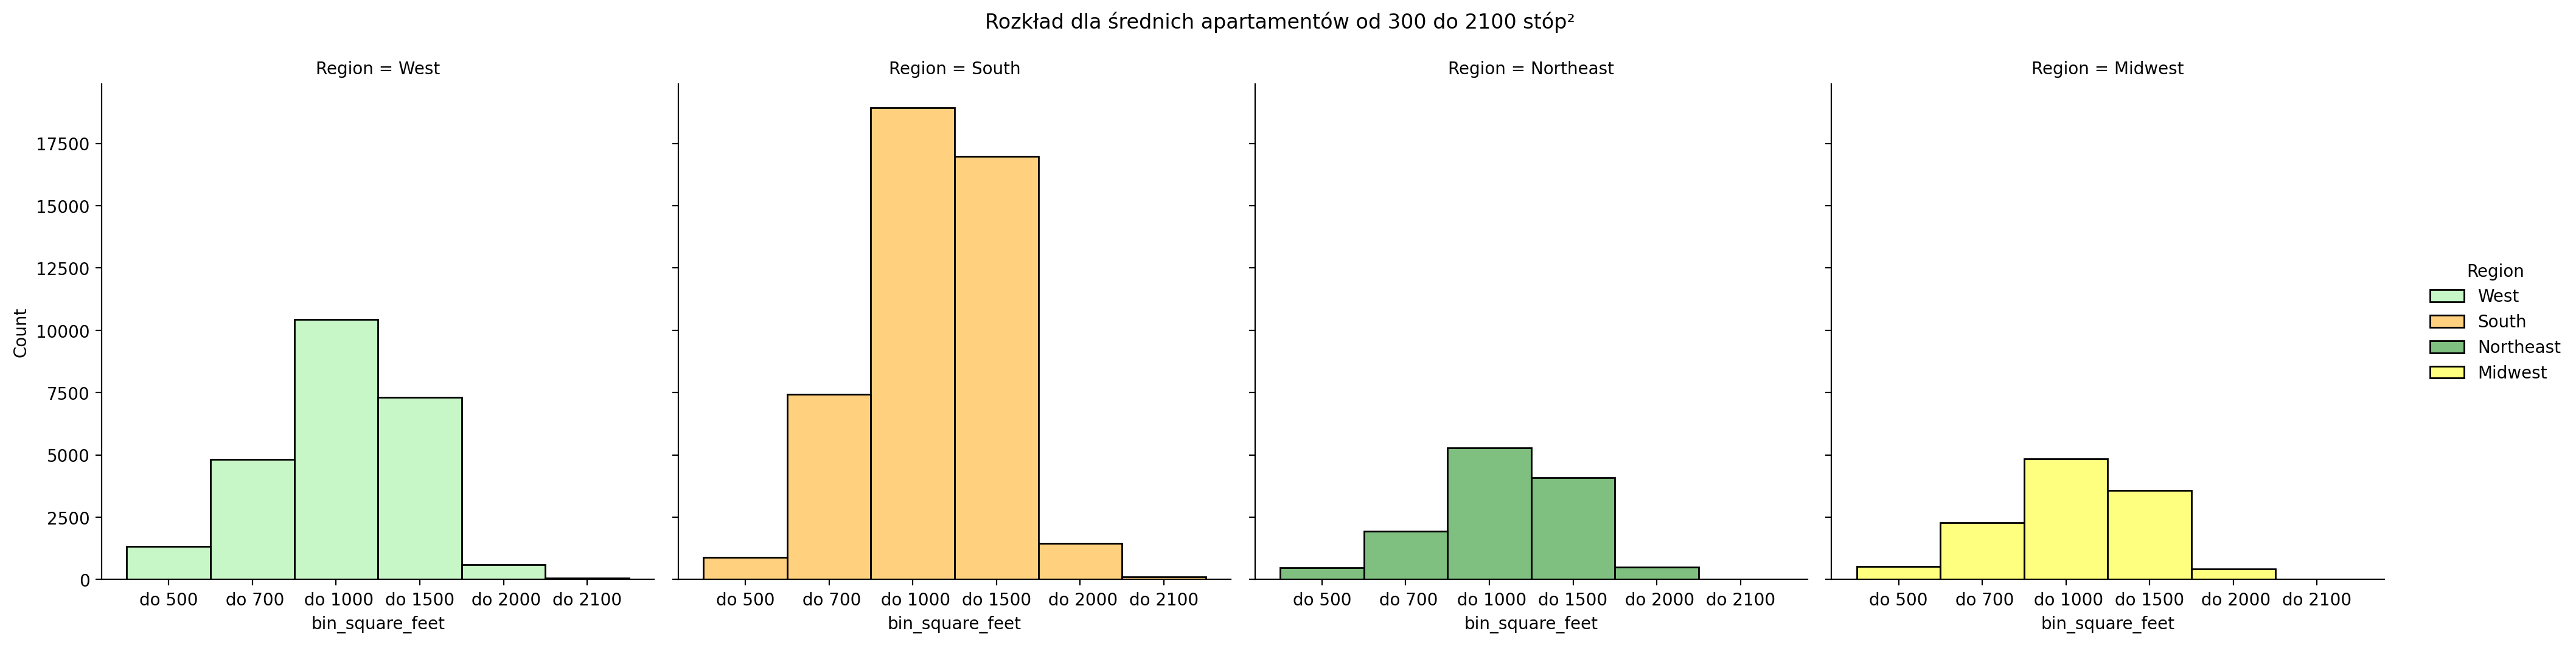

In [98]:
sns.displot(
    data=df2,
    x="bin_square_feet",
    col="Region",
    hue="Region",
    palette=region_colors
    
)

plt.suptitle("Rozkład dla średnich apartamentów od 300 do 2100 stóp² ", y=1.05)
plt.show()


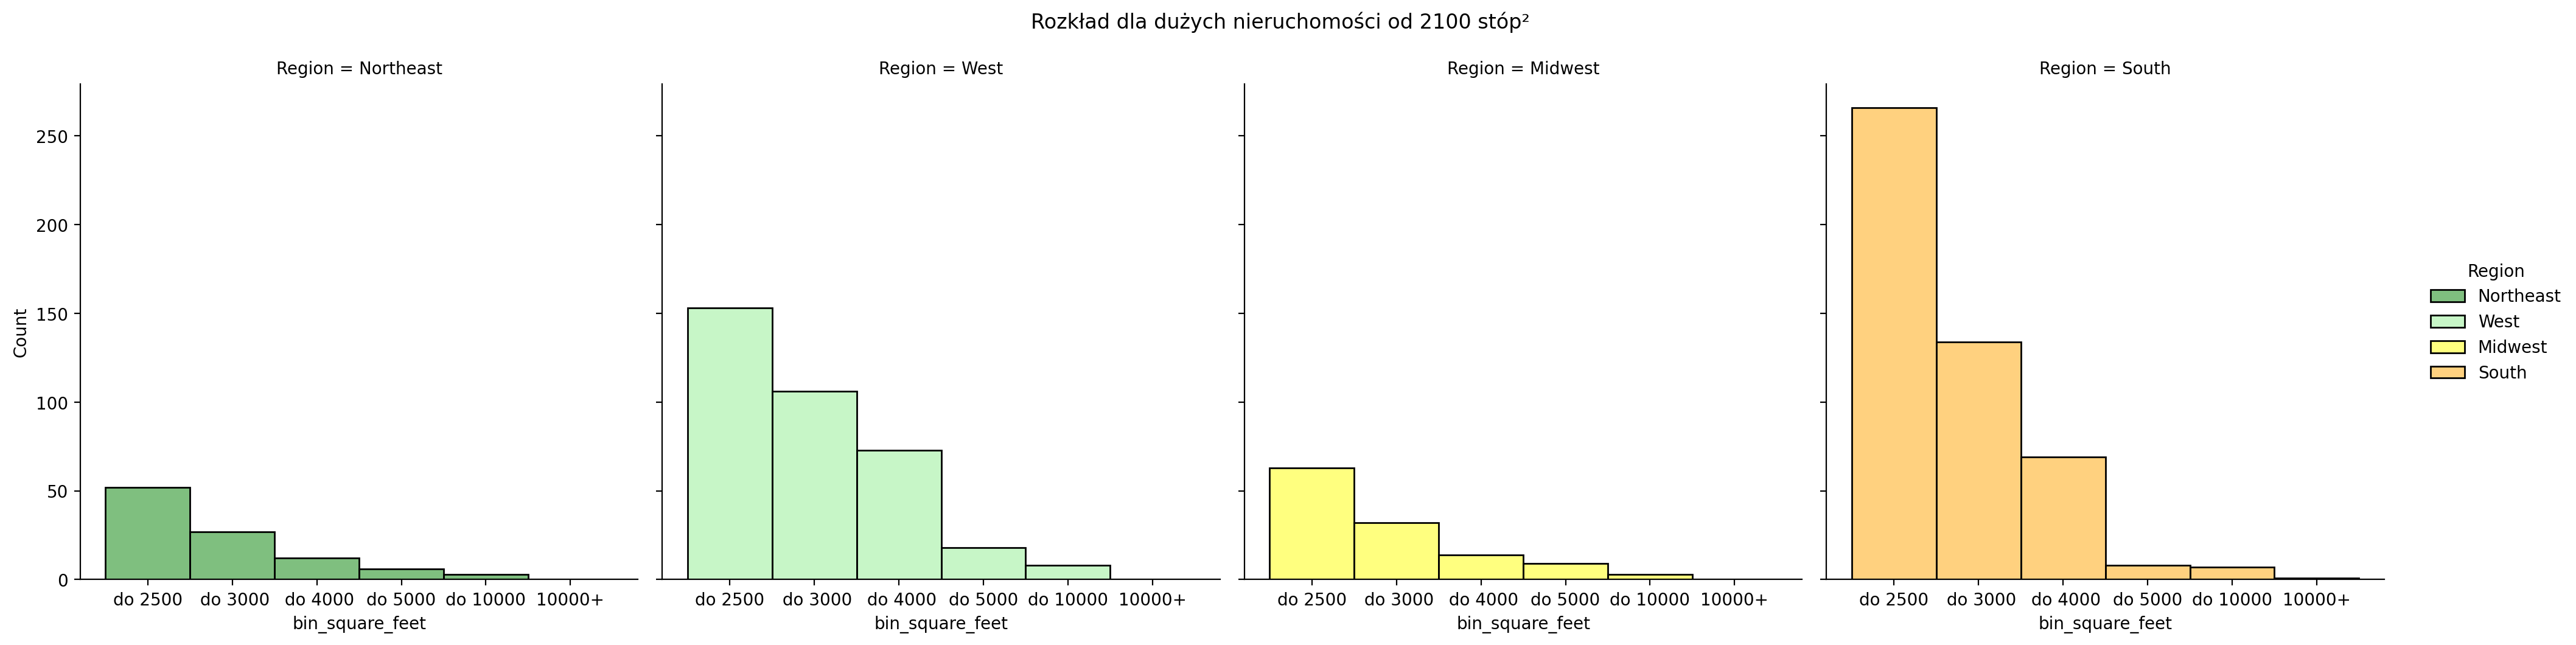

In [99]:
sns.displot(
    data=df3,
    x="bin_square_feet",
    col="Region",
    hue="Region",
    palette=region_colors
    
)

plt.suptitle("Rozkład dla dużych nieruchomości od 2100 stóp² ", y=1.05)
plt.show()

In [100]:
# wykres na którym na osi x będzie region, na osi y przedział_powierzchni, 
# kolorem określony charakter, a wielkość kropki ma obrazować ilość linii w pliku odpowiadających kropce.

# zliczenie rekordów dla każdej kombinacji
agg = (
    df.groupby(
        ["charakter", "bin_square_feet", "Region"]
    )
    .size()
    .reset_index(name="liczba")
)

#print(agg.head())

# wykres
fig = px.scatter(
    agg,
    x="Region",
    y="bin_square_feet",
    color="charakter",
    color_discrete_map=charakter_colors,
    size="liczba",
    size_max=60,
    hover_data=["liczba"],
    labels={
             "bin_square_feet": "Przedział powierzchni (stóp²)"
    },
    title="Liczba ofert wg Regionu USA, przedziału powierzchni i charakteru"
)

#fig.update_layout(
#    width=1200,
#    height=800
#)

fig.show()


C:\Users\mhi\AppData\Local\Temp\ipykernel_30900\209697783.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


In [101]:
df_West = df[(df["Region"] == "West")]

df_West.head(3)
agg_West = (
    df_West.groupby(
        ["charakter", "bin_square_feet", "state"]
    )
    .size()
    .reset_index(name="liczba")
)

# wykres
fig = px.scatter(
    agg_West,
    x="state",
    y="bin_square_feet",
    color="charakter",
    color_discrete_map=charakter_colors,
    size="liczba",
    size_max=60,
    hover_data=["liczba"],
    labels={
        "charakter": "Charakter regionu",
        "bin_square_feet": "Przedział powierzchni (stóp²)"
    },
    title="Liczba ofert wg charakteru, przedziału powierzchni dla Regionu West USA"
)

fig.update_layout()



C:\Users\mhi\AppData\Local\Temp\ipykernel_30900\3995511150.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_West.groupby(


In [102]:
df_South = df[(df["Region"] == "South")]

df_South.head(3)
agg_South = (
    df_South.groupby(
        ["charakter", "bin_square_feet", "state"]
    )
    .size()
    .reset_index(name="liczba")
)

# wykres
fig = px.scatter(
    agg_South,
    x="state",
    y="bin_square_feet",
    color="charakter",
    color_discrete_map=charakter_colors,
    size="liczba",
    size_max=60,
    hover_data=["liczba"],
    labels={
        "charakter": "Charakter regionu",
        "bin_square_feet": "Przedział powierzchni (stóp²)"
    },
    title="Liczba ofert wg charakteru, przedziału powierzchni dla Regionu South USA"
)

fig.update_layout()



C:\Users\mhi\AppData\Local\Temp\ipykernel_30900\1969980570.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_South.groupby(


In [103]:
df_Northeast = df[(df["Region"] == "Northeast")]

df_Northeast.head(3)
agg_Northeast = (
    df_Northeast.groupby(
        ["charakter", "bin_square_feet", "state"]
    )
    .size()
    .reset_index(name="liczba")
)

# wykres
fig = px.scatter(
    agg_Northeast,
    x="state",
    y="bin_square_feet",
    color="charakter",
    color_discrete_map=charakter_colors,
    size="liczba",
    size_max=60,
    hover_data=["liczba"],
    labels={
        "charakter": "Charakter regionu",
        "bin_square_feet": "Przedział powierzchni (stóp²)"
    },
    title="Liczba ofert wg charakteru, przedziału powierzchni dla Regionu Northeast USA"
)

fig.update_layout()


C:\Users\mhi\AppData\Local\Temp\ipykernel_30900\258032000.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_Northeast.groupby(


In [104]:
df_Midwest = df[(df["Region"] == "Midwest")]

df_Midwest.head(3)
agg_Midwest = (
    df_Midwest.groupby(
        ["charakter", "bin_square_feet", "state"]
    )
    .size()
    .reset_index(name="liczba")
)

# wykres
fig = px.scatter(
    agg_Midwest,
    x="state",
    y="bin_square_feet",
    color="charakter",
    color_discrete_map=charakter_colors,
    size="liczba",
    size_max=60,
    hover_data=["liczba"],
    labels={
        "charakter": "Charakter regionu",
        "bin_square_feet": "Przedział powierzchni (stóp²)"
    },
    title="Liczba ofert wg charakteru, przedziału powierzchni dla Regionu Midwest USA"
)

fig.update_layout()

C:\Users\mhi\AppData\Local\Temp\ipykernel_30900\786634108.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_Midwest.groupby(


Interpretacja wyniku

Wykresy obrazują charakter różnych regionów i stanów zgodnie z dołączonym mapowanim. 
Nie widać dużej zależności powierzchni oferowanych nieruchomości od charakteru stanu. Najwięcej ofert jest w przedziale nieruchomości średnich niezależnie od regionu. 

Wcześniej w tekście przy wykresie dotyczącym małych nieruchomości wskazano zależność - wśród nieruchomości małych Regiony Northeast oraz Midwest mają przewagę ofert z przedziału 250 - 300 stóp²
Dla pozostałych większość tego typu ofert dotyczy przedziału 200 - 250 stóp²

#### <span style="color: deepskyblue;">Analiza dotycząca ogólnego rozkładu cen  </span>



Liczba ofert: 95771
Średnia cena: 1530.90 USD
Mediana ceny: 1355.00 USD
Odchylenie standardowe: 872.60 USD
Przedział kwartylowy (IQR): 1022.00 USD - 1795.00 USD


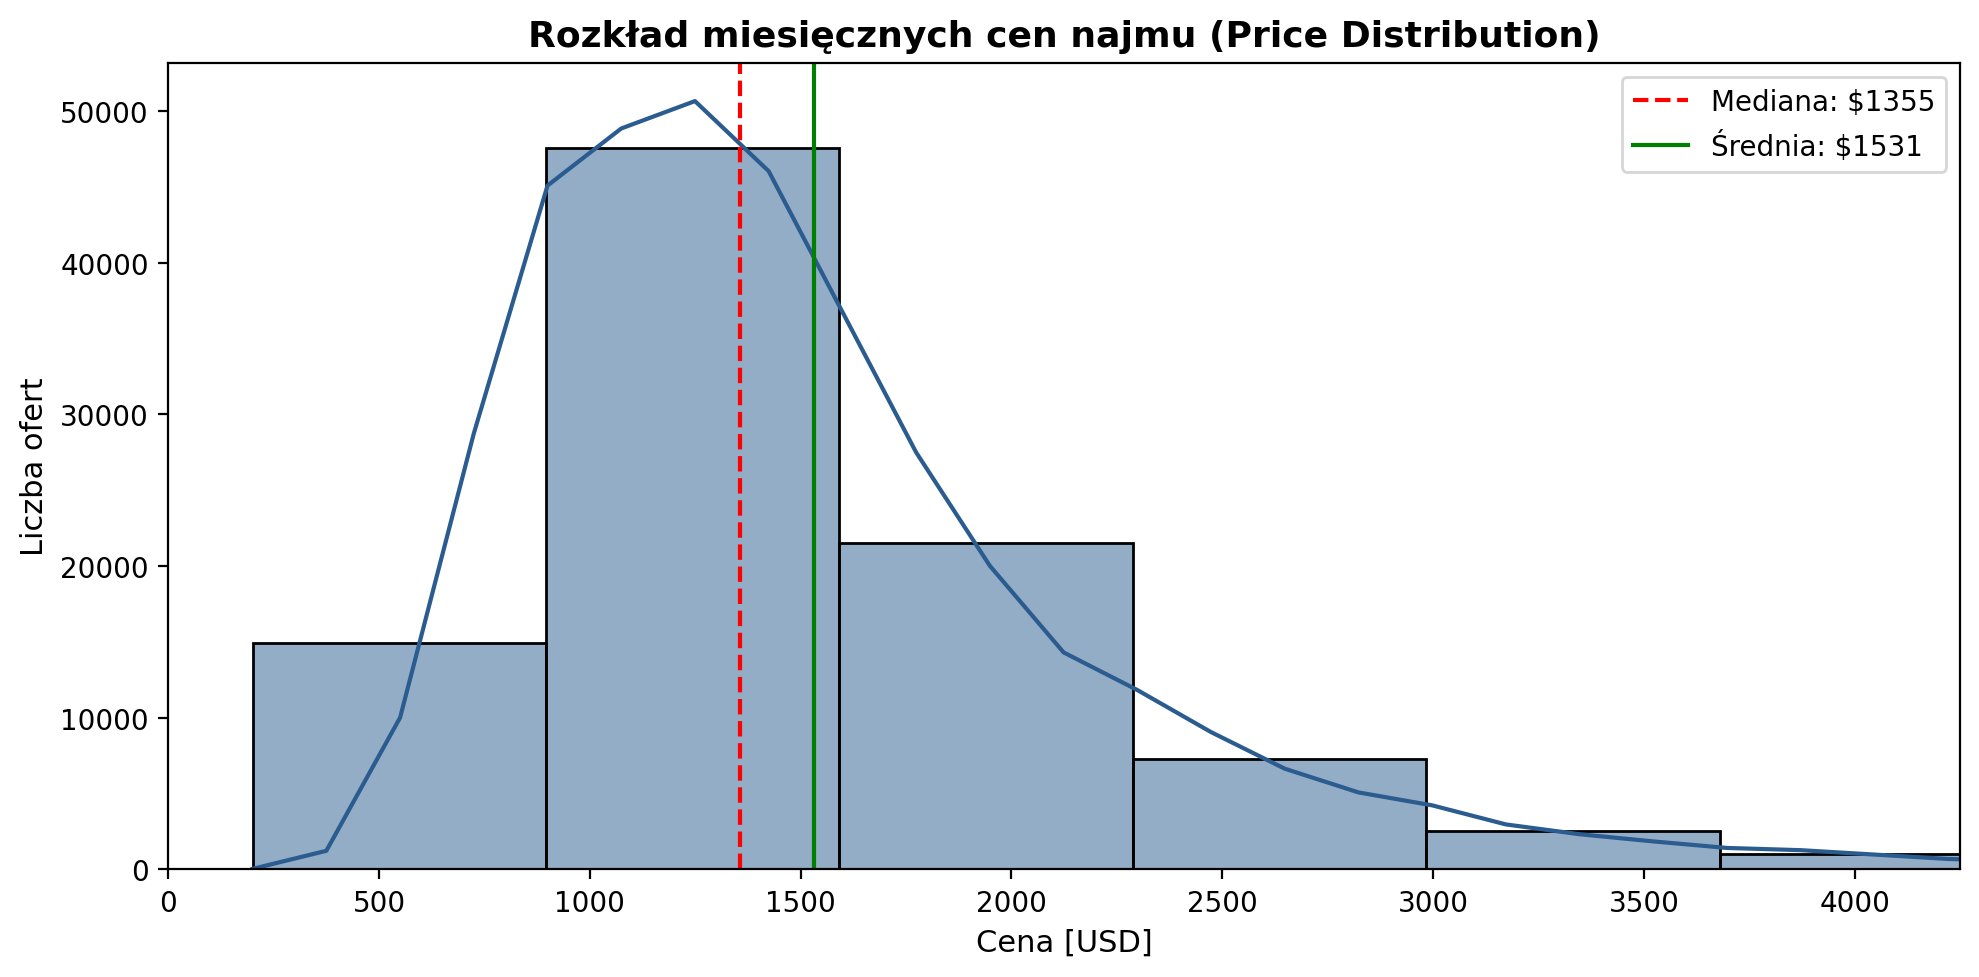

In [105]:
df = pd.read_csv("data/apartments_clean.csv", sep=';', encoding="cp1250", low_memory=False)

# Wyliczenie statystyk
srednia = df['price'].mean()
mediana = df['price'].median()
std_dev = df['price'].std()
kwartyl_25 = df['price'].quantile(0.25)
kwartyl_75 = df['price'].quantile(0.75)

print(f'Liczba ofert: {len(df)}')
print(f'Średnia cena: {srednia:.2f} USD')
print(f'Mediana ceny: {mediana:.2f} USD')
print(f'Odchylenie standardowe: {std_dev:.2f} USD')
print(f'Przedział kwartylowy (IQR): {kwartyl_25:.2f} USD - {kwartyl_75:.2f} USD')

# Wizualizacja rozkładu
plt.figure(figsize=(10, 5))
sns.histplot(
    df['price'], bins=50, kde=True, color='#2b5c8f', edgecolor='black'
)

# Tytuł i etykiety osi
plt.title(
    'Rozkład miesięcznych cen najmu (Price Distribution)',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('Cena [USD]', fontsize=11)
plt.ylabel('Liczba ofert', fontsize=11)

# Ograniczenie widoku osi X do 99. percentyla dla czytelności
plt.xlim(0, df['price'].quantile(0.99))

# Linie reprezentujące średnią oraz medianę
plt.axvline(
    mediana, color='red', linestyle='--', label=f'Mediana: ${mediana:.0f}'
)
plt.axvline(srednia, color='green', linestyle='-', label=f'Średnia: ${srednia:.0f}')

plt.legend()
plt.tight_layout()
plt.show()

##### Ogólny rozkład cen najmu.
Skośność prawostronna: Rozkład cen jest wyraźnie asymetryczny. Większość ofert koncentruje się w przedziale $900–1600\text{ USD}$.Przekłamanie średniej: Średnia cena ($1531\text{ USD}$) jest zawyżona o $176\text{ USD}$ względem mediany ($1355\text{ USD}$) z powodu obecności nielicznych, luksusowych ofert w prawym ogonie rozkładu ($>3000\text{ USD}$).Wniosek: Mediana ($1355\text{ USD}$) stanowi właściwą miarę punktu odniesienia dla przeciętnego czynszu na tym rynku.

STATYSTYKI [USD / sq ft] 
Mediana: 1.48 
Średnia: 1.69 
Przedział IQR (25%-75%): 1.13 - 2.00 


C:\Users\mhi\AppData\Local\Temp\ipykernel_30900\1154732792.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


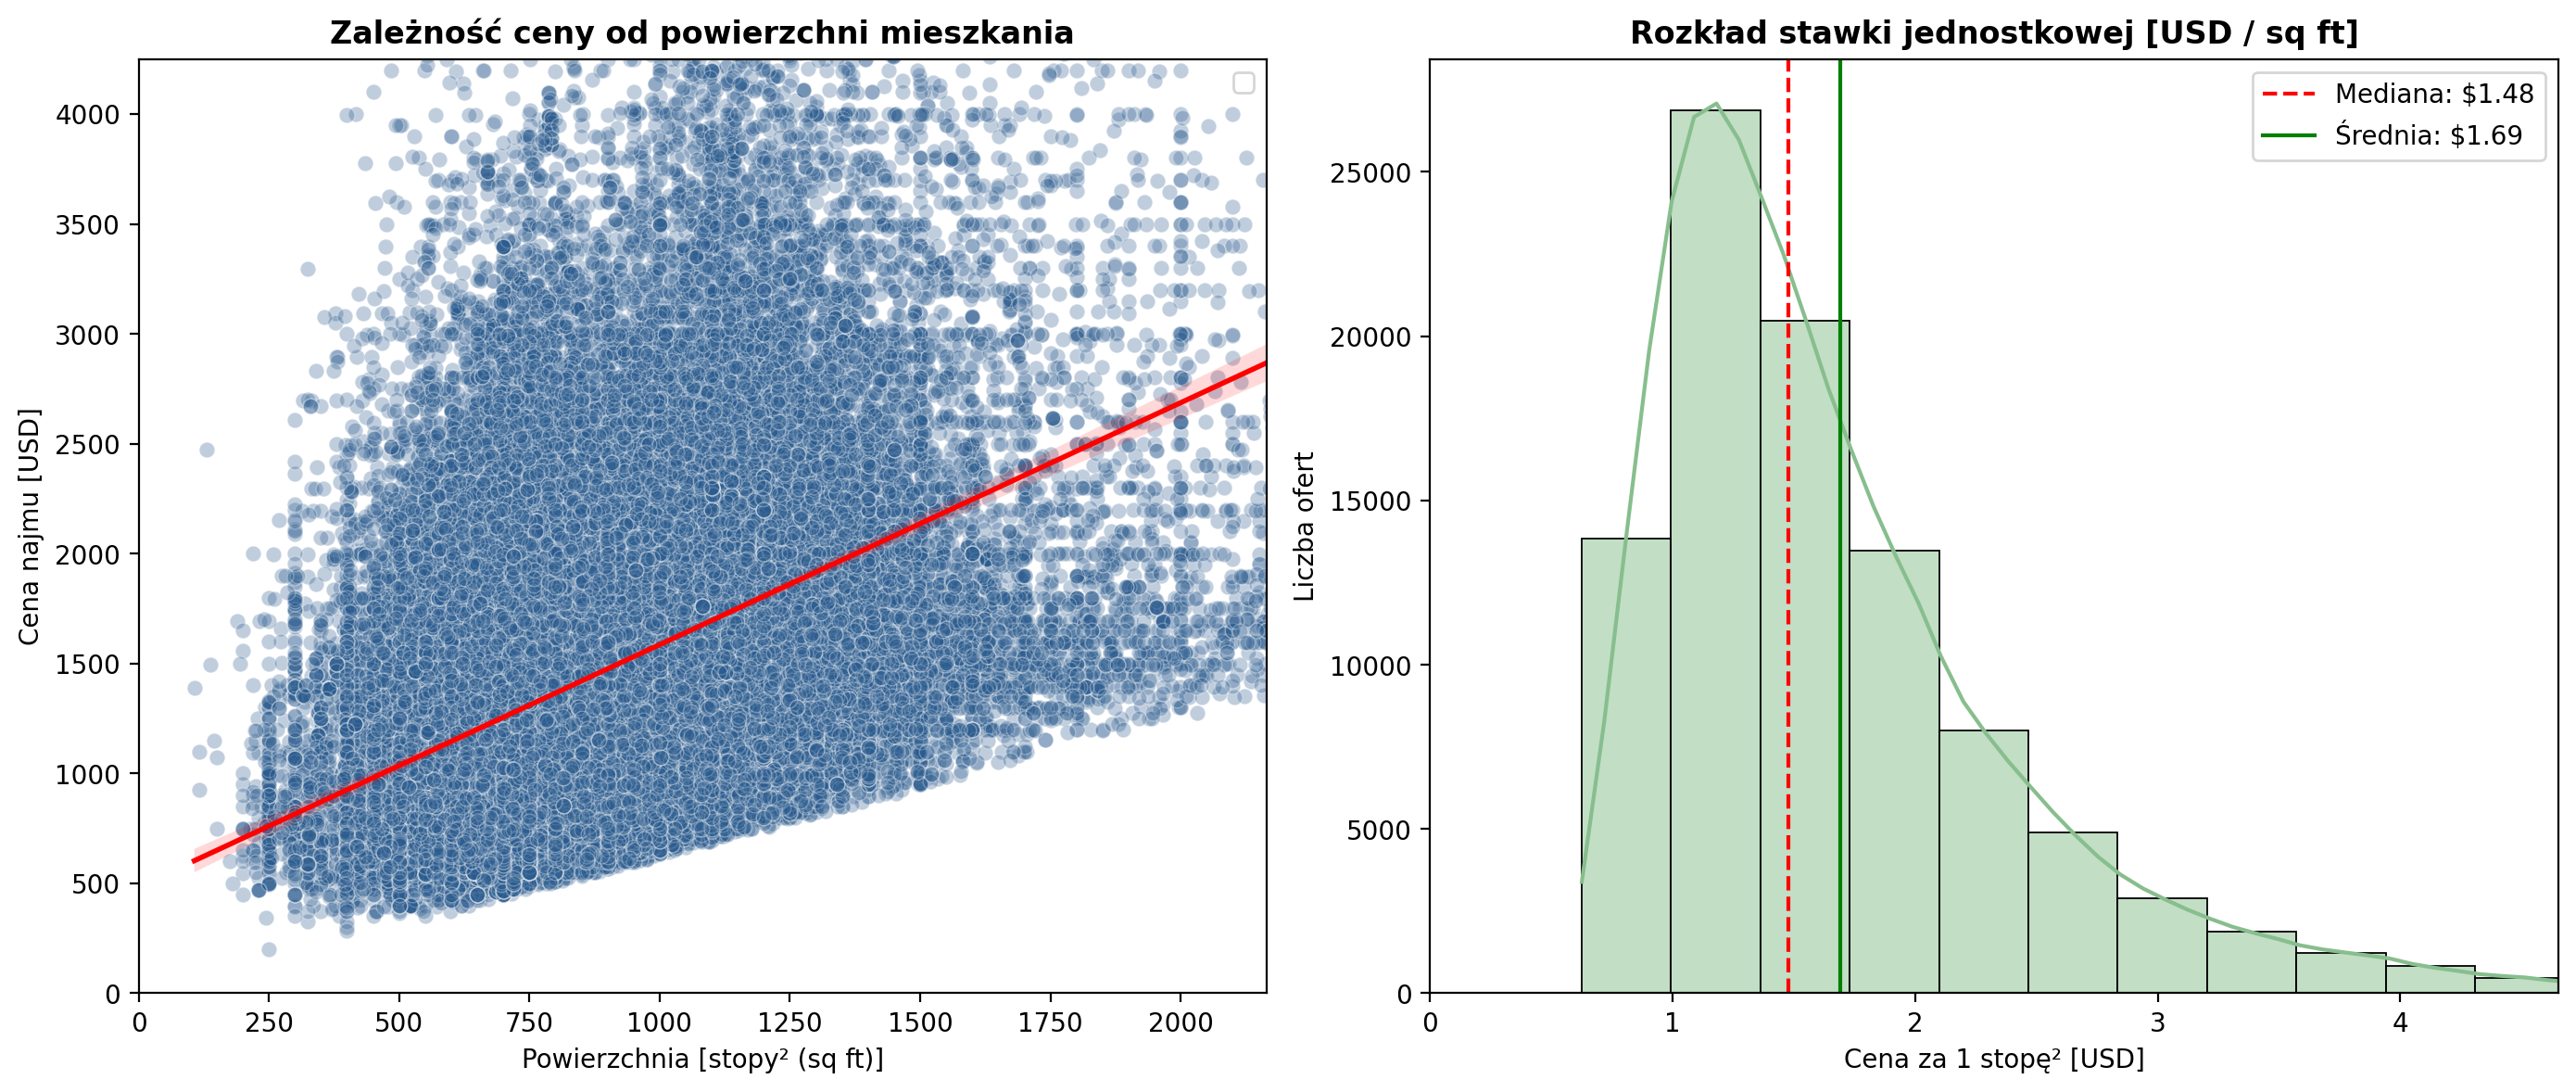

In [106]:

# Wyliczenie stawki jednostkowej
df['price_per_sqft'] = df['price'] / df['square_feet']

# Wyliczenie statystyk opisowych
sqft_stats = {
    'mediana': df['price_per_sqft'].median(),
    'srednia': df['price_per_sqft'].mean(),
    'q25': df['price_per_sqft'].quantile(0.25),
    'q75': df['price_per_sqft'].quantile(0.75),
}

# Wydruk wyników w konsoli
print("STATYSTYKI [USD / sq ft] ")
print(f"Mediana: {sqft_stats['mediana']:.2f} ")
print(f"Średnia: {sqft_stats['srednia']:.2f} ")
print(
    f"Przedział IQR (25%-75%): {sqft_stats['q25']:.2f} -"
    f" {sqft_stats['q75']:.2f} "
)

# Inicjalizacja siatki wykresów (1x2)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# LEWY WYKRES: Zależność Ceny od Powierzchni
sns.scatterplot(
    data=df, x='square_feet', y='price', alpha=0.3, color='#2b5c8f', ax=axes[0]
)  # Punkty danych
sns.regplot(
    data=df,
    x='square_feet',
    y='price',
    scatter=False,
    ax=axes[0],
    color='red',
    line_kws={'linewidth': 2, 'label': 'Linia trendu'},
)  # Linia regresji

# Formatowanie lewego wykresu (tytuł, osie, limity)
axes[0].set_title(
    'Zależność ceny od powierzchni mieszkania', fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Powierzchnia [stopy² (sq ft)]', fontsize=10)
axes[0].set_ylabel('Cena najmu [USD]', fontsize=10)
axes[0].set_xlim(0, df['square_feet'].quantile(0.99))
axes[0].set_ylim(0, df['price'].quantile(0.99))
axes[0].legend()

# PRAWY WYKRES: Stawka jednostkowa
sns.histplot(
    df['price_per_sqft'],
    bins=50,
    kde=True,
    ax=axes[1],
    color='#87be8d',
    edgecolor='black',
)  # Histogram z populacją
axes[1].axvline(
    sqft_stats['mediana'],
    color='red',
    linestyle='--',
    label=f"Mediana: ${sqft_stats['mediana']:.2f}",
)  # Linia mediany
axes[1].axvline(
    sqft_stats['srednia'],
    color='green',
    linestyle='-',
    label=f"Średnia: ${sqft_stats['srednia']:.2f}",
)  # Linia średniej

# Formatowanie prawego wykresu (tytuł, osie, limity)
axes[1].set_title(
    'Rozkład stawki jednostkowej [USD / sq ft]', fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('Cena za 1 stopę² [USD]', fontsize=10)
axes[1].set_ylabel('Liczba ofert', fontsize=10)
axes[1].set_xlim(0, df['price_per_sqft'].quantile(0.99))
axes[1].legend(loc='upper right')

# Finalizacja i wyświetlenie
plt.tight_layout()
plt.show()

##### Zależność ceny od powierzchni (Wykres lewy)
Linia trendu wykazuje stały wzrost ceny wraz ze wzrostem metrażu (od ok. $600\text{ USD}$ przy $200\text{ sq ft}$ do ponad $2800\text{ USD}$ przy $2000\text{ sq ft}$).   Możemy zauważyć wysokie rozproszenie przy stałym metrażu (np. $1000\text{ sq ft}$) ceny wahają się od $800\text{ USD}$ do ponad $4000\text{ USD}$. Można z tego wysnuć wniosek, że powierzchnia wyjaśnia tylko część zmienności ceny. Istotną rolę odgrywają zmienne lokalizacyjne oraz standard wykończenia.
##### Stawka jednostkowa [USD / sq ft] (Wykres prawy)
Miernik opłacalności: Mediana stawki jednostkowej wynosi $1.48\text{ USD/sq ft}$, podczas gdy średnia wynosi $1.69\text{ USD/sq ft}$.Koncentracja rynku: Największe zagęszczenie ofert występuje w wąskim przedziale $1.00–1.50\text{ USD/sq ft}$.Wniosek: Stawki powyżej $2.50\text{ USD/sq ft}$ stanowią odosobniony segment rynkowy (lokalizacje w ścisłych centrach metropolii lub apartamentowce o wysokim standardzie).

#### <span style="color: deepskyblue;">Analiza dotycząca wpływu udogodnień na cene </span>

 10 udogodnien pod wzgledem wplywu na cene 
Udogodnienie  Liczba_ofert  Mediana_Z  Mediana_Bez  Roznica_USD  Wzrost_Mediany_Pct
     Doorman           204     2417.5       1353.0       1064.5           78.677014
    Elevator          4196     1685.5       1345.0        340.5           25.315985
 Wood Floors          8426     1541.0       1344.0        197.0           14.657738
        View          2030     1540.0       1350.0        190.0           14.074074
      Luxury           201     1485.0       1354.0        131.0            9.675037
     Hot Tub          3900     1430.5       1350.0         80.5            5.962963
          TV          4365     1424.0       1350.0         74.0            5.481481
     Parking         42344     1383.0       1335.0         48.0            3.595506
       Gated          8426     1395.0       1350.0         45.0            3.333333
         Gym         36255     1370.0       1350.0         20.0            1.481481


C:\Users\mhi\AppData\Local\Temp\ipykernel_30900\1159856624.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


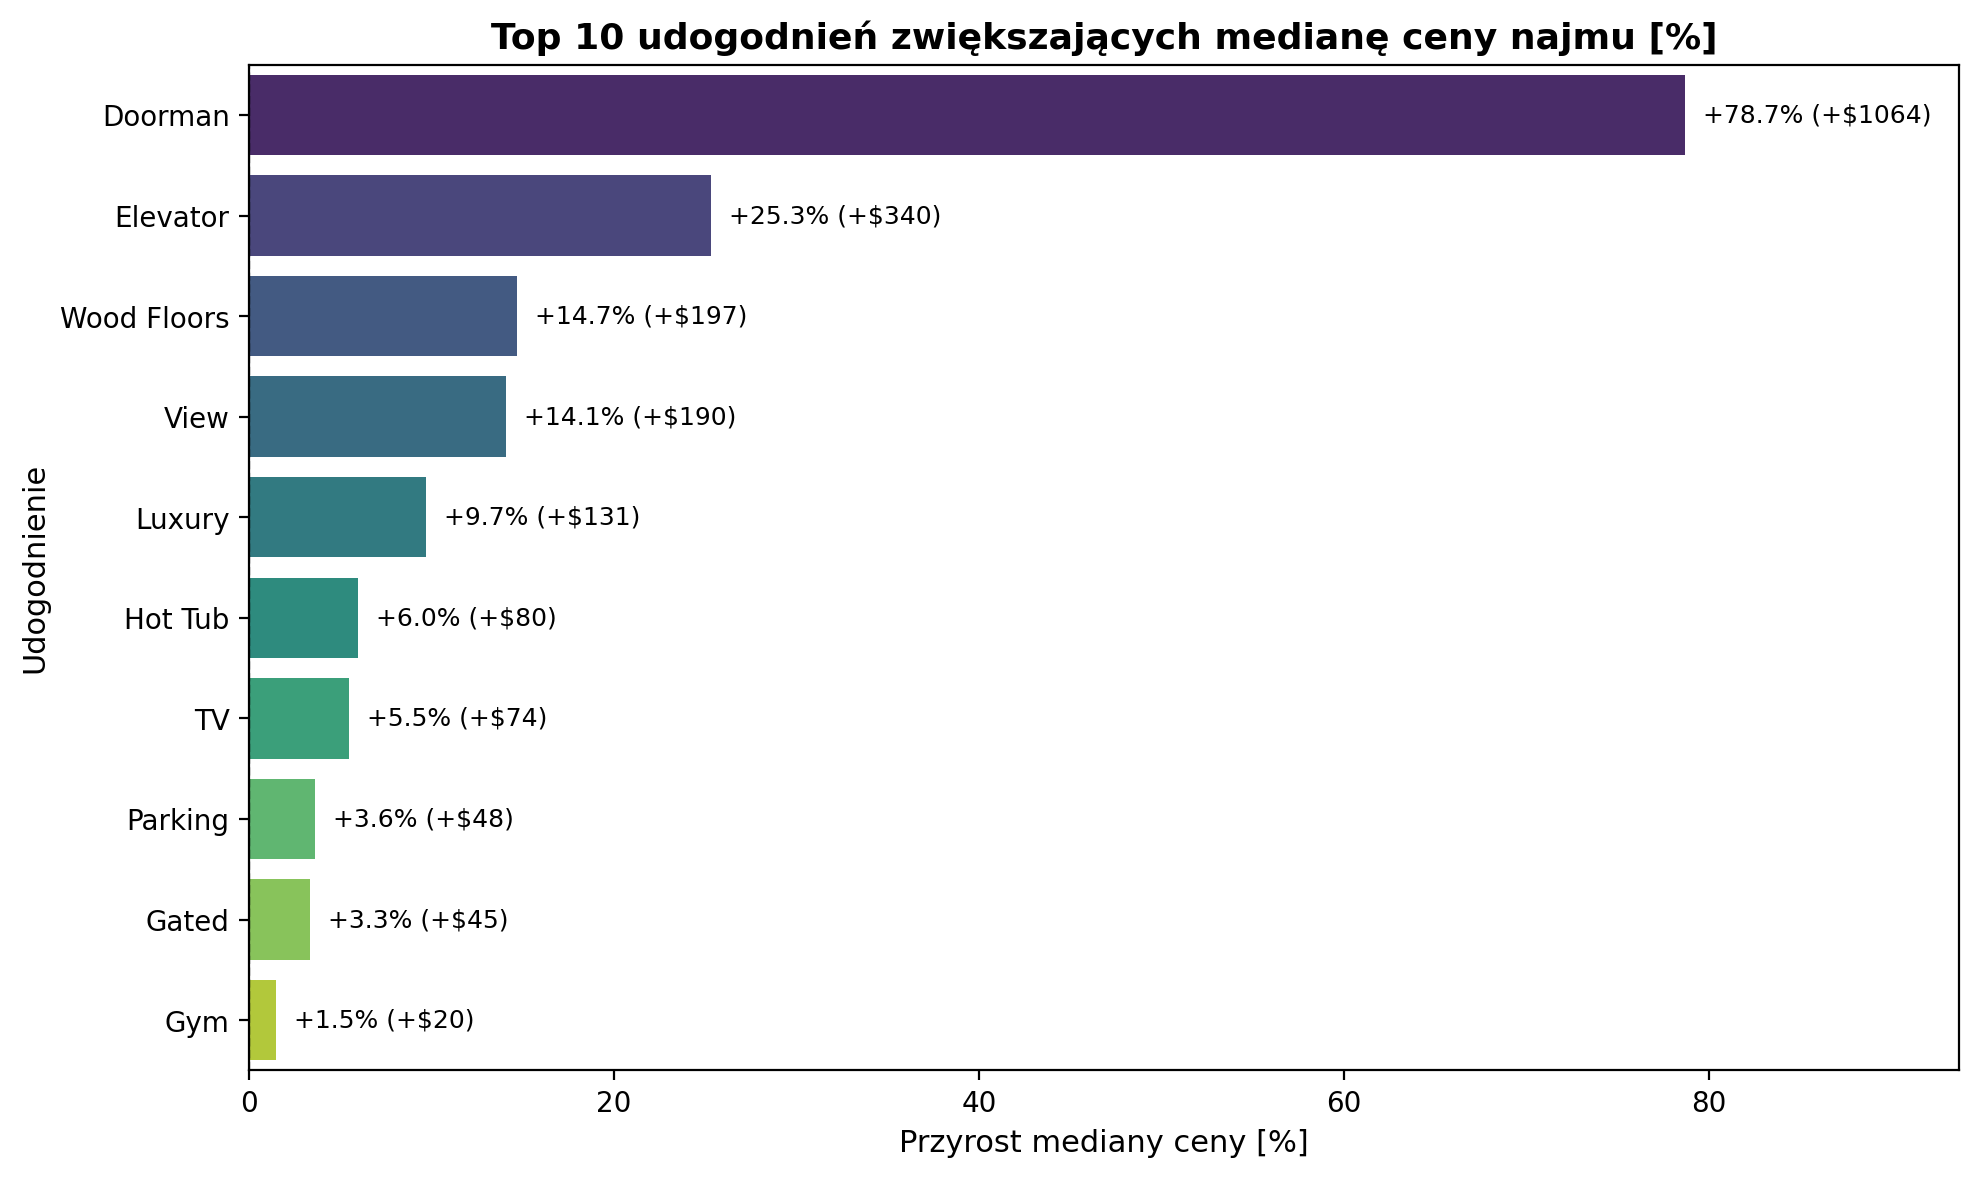

In [107]:
# Pobranie kolumn z zakresu w pliku
istniejace = df.loc[:, 'AC':'Wood Floors'].columns.tolist()
# korzystamy z macierzy binarnej i sprawdzamy udogodnienia 1 znaczy ze wystepuja 0 ze nie wystepuja
wyniki = []

for feature in istniejace:
    mediana_z = df[df[feature] == 1]['price'].median()
    mediana_bez = df[df[feature] == 0]['price'].median()
    srednia_z = df[df[feature] == 1]['price'].mean()
    srednia_bez = df[df[feature] == 0]['price'].mean()
    liczba_z = (df[feature] == 1).sum()
    
    roznica_mediana = mediana_z - mediana_bez
    procent_mediana = (roznica_mediana / mediana_bez) * 100
    # Tworzymy tabele z wynikami
    wyniki.append({
        'Udogodnienie': feature,
        'Liczba_ofert': liczba_z,
        'Udzial_Pct': (liczba_z / len(df)) * 100,
        'Mediana_Z': mediana_z,
        'Mediana_Bez': mediana_bez,
        'Roznica_USD': roznica_mediana,
        'Wzrost_Mediany_Pct': procent_mediana,
        'Srednia_Z': srednia_z,
        'Srednia_Bez': srednia_bez
    })
# Na tym etapie sortujemy wartości malejąco i pokazujemy tylko top 10
df_analiza = pd.DataFrame(wyniki).sort_values(by='Wzrost_Mediany_Pct', ascending=False)


print(" 10 udogodnien pod wzgledem wplywu na cene ")
print(df_analiza[['Udogodnienie', 'Liczba_ofert', 'Mediana_Z', 'Mediana_Bez', 'Roznica_USD', 'Wzrost_Mediany_Pct']].head(10).to_string(index=False))

# Część tworzenia wykresów zaczynamy od okreslenia wielkosci i zakresu danych
plt.figure(figsize=(10, 6))
top_10 = df_analiza.head(10)
# Przypisujemy wartości do osi
sns.barplot(
    data=top_10, 
    x='Wzrost_Mediany_Pct', 
    y='Udogodnienie', 
    palette='viridis'
)
# Nazywamy osie i wykres
plt.title('Top 10 udogodnień zwiększających medianę ceny najmu [%]', fontsize=13, fontweight='bold')
plt.xlabel('Przyrost mediany ceny [%]', fontsize=11)
plt.ylabel('Udogodnienie', fontsize=11)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
# A tu mały bajer tworzymy koło słupków odpowiadajace im wartości
for idx, row in top_10.reset_index(drop=True).iterrows():
    val = row['Wzrost_Mediany_Pct']
    diff = row['Roznica_USD']
    plt.text(val + 1.0, idx, f"+{val:.1f}% (+${diff:.0f})", va='center', fontsize=9)

plt.xlim(0, top_10['Wzrost_Mediany_Pct'].max() + 15)
plt.tight_layout()
plt.show()

#### <span style="color: deepskyblue;">Dodatkowa analiza </span>

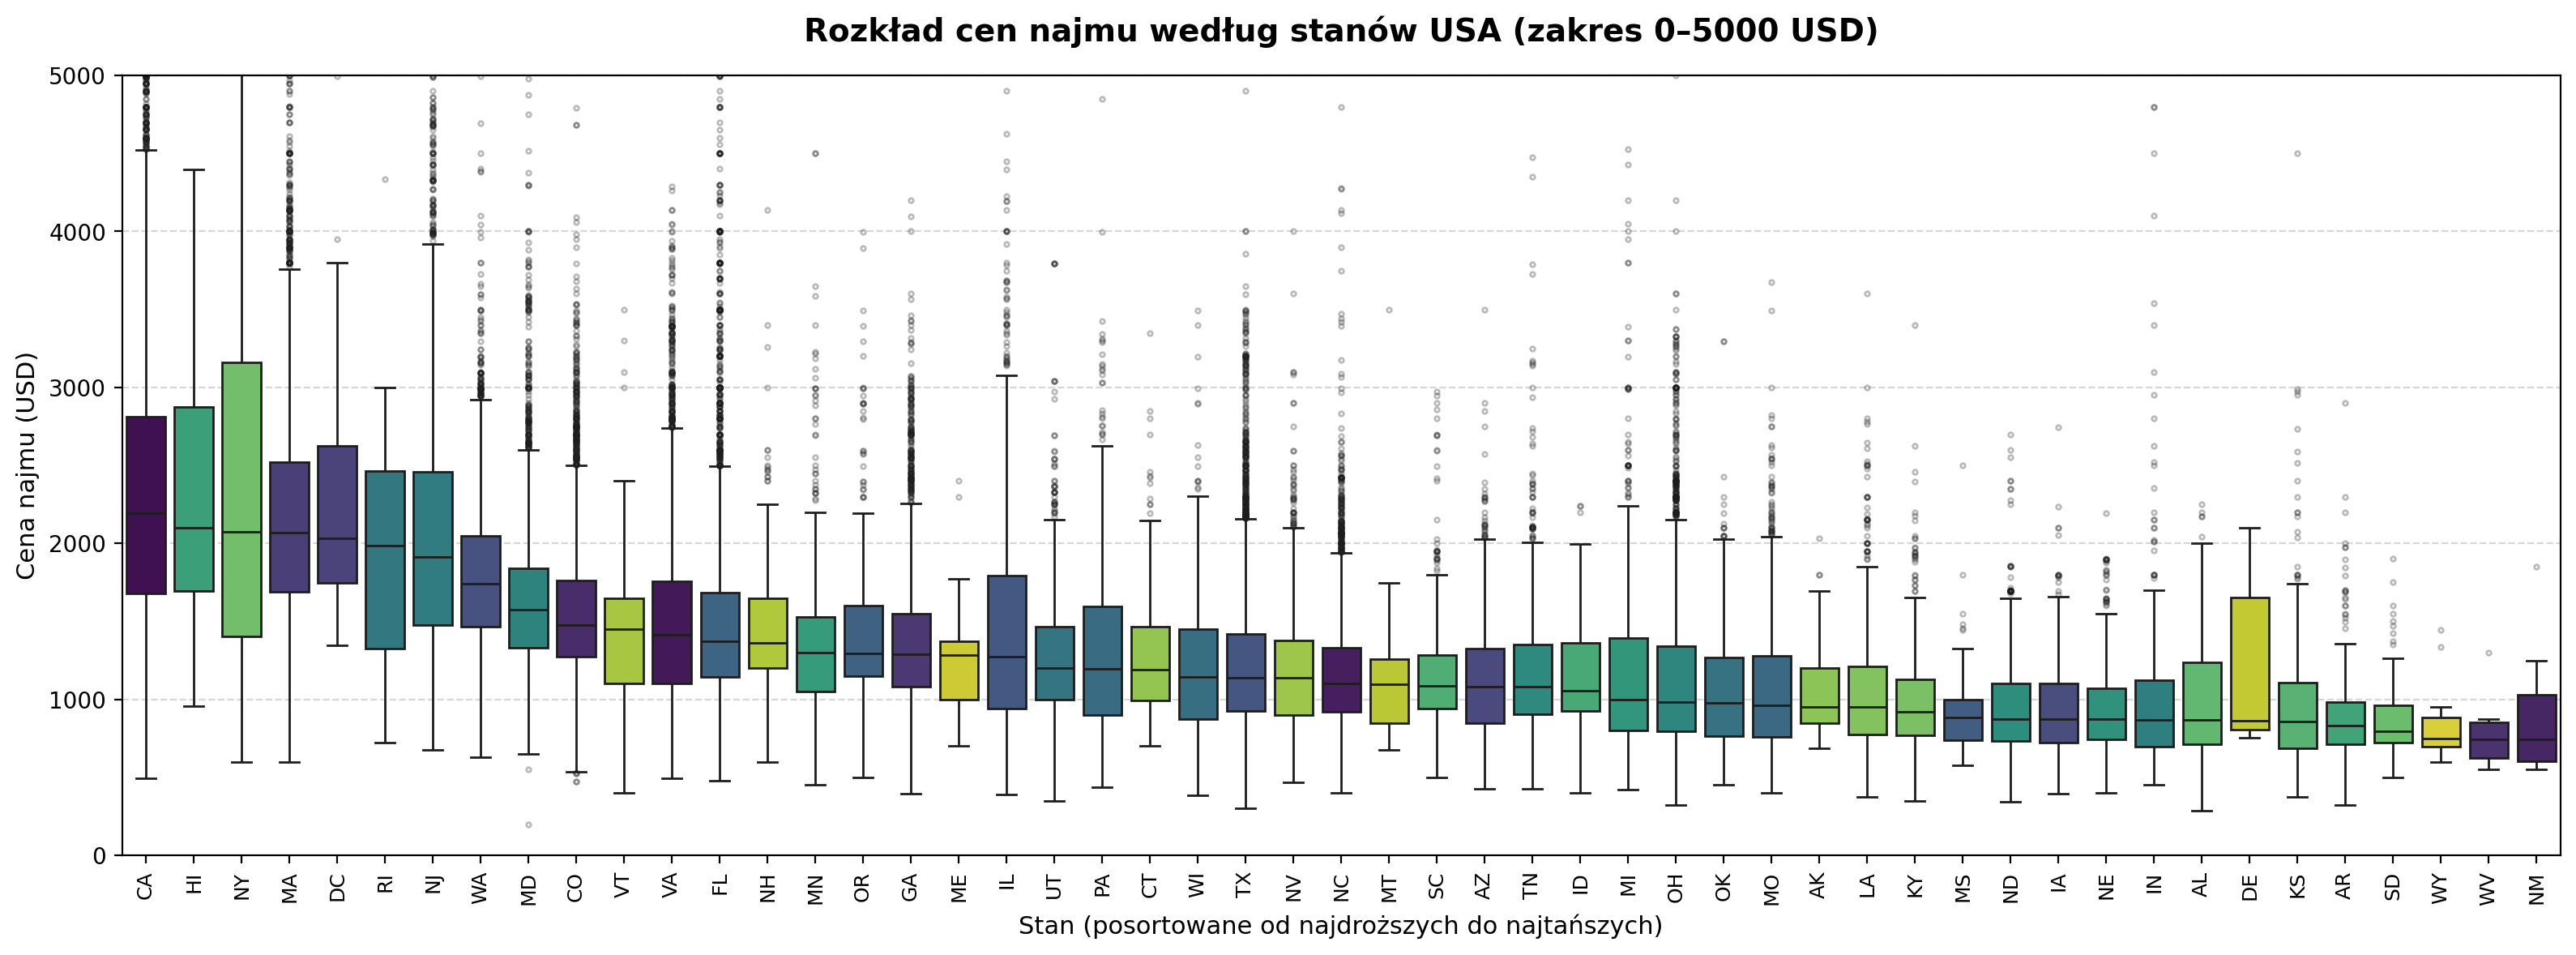

In [108]:
# 1. Posortowanie stanów według mediany ceny (żeby wykres tworzył ładny ciąg)
kolejnosc_stanow = (
    df.groupby("state")["price"].median().sort_values(ascending=False).index
)

# 2. Ustawienie rozmiaru
plt.figure(figsize=(16, 6))

# 3. Rysowanie boxplota z mniejszymi kropkami dla outlierów
sns.boxplot(
    data=df,
    x="state",
    y="price",
    order=kolejnosc_stanow,
    hue="state",
    palette="viridis",
    legend=False,
    fliersize=2,  # Zmniejszamy rozmiar kropek outlierów
    flierprops={"alpha": 0.3},  # Przepuszczalność światła (przezroczystość) kropek
)

# 4. Kluczowy krok: Przycinamy oś Y, aby zobaczyć główne pudełka!
plt.ylim(0, 5000)

# 5. Stylistyka i podpisy
plt.title(
    "Rozkład cen najmu według stanów USA (zakres 0–5000 USD)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Stan (posortowane od najdroższych do najtańszych)", fontsize=11)
plt.ylabel("Cena najmu (USD)", fontsize=11)
plt.xticks(rotation=90, fontsize=9)
plt.grid(axis="y", linestyle="--", alpha=0.5)  # Delikatna pozioma siatka

plt.tight_layout()
plt.show()

C:\Users\mhi\AppData\Local\Temp\ipykernel_30900\446883022.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='state', y='price', data=df_top_states, palette='rocket')


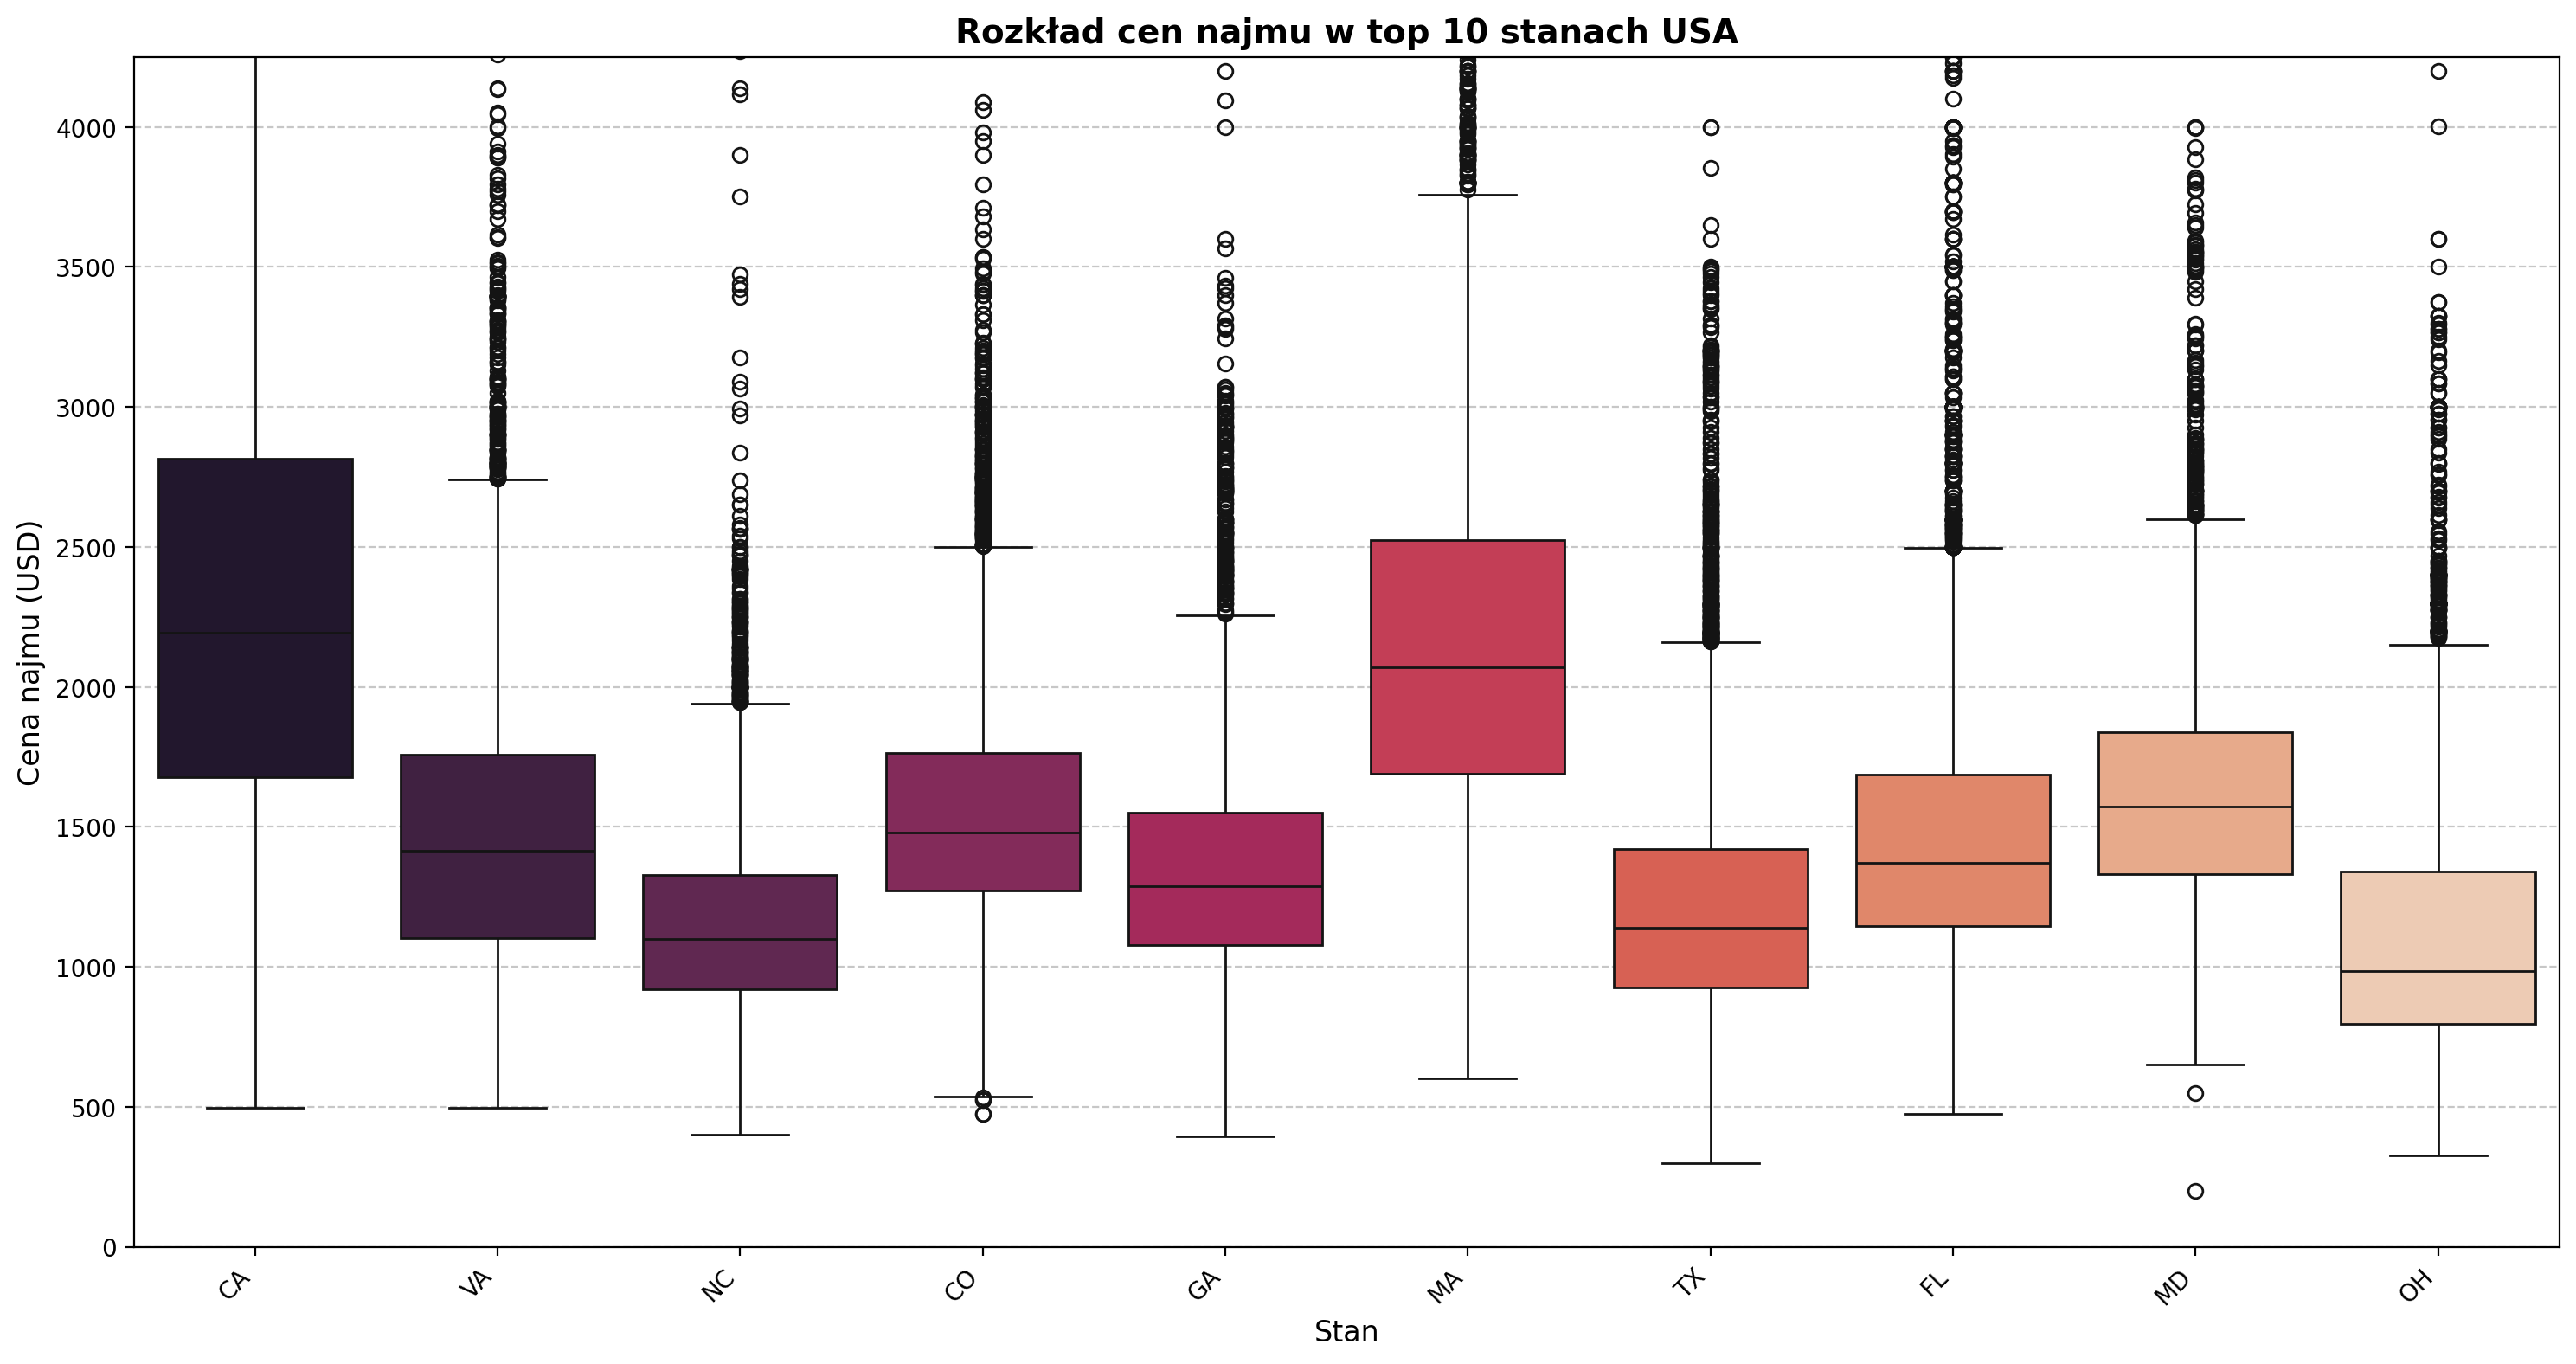

In [109]:
# Rozkład cen najmu według stanu (top 10 stanów z największą liczbą ofert)

top_states = df['state'].value_counts().nlargest(10).index
df_top_states = df[df['state'].isin(top_states)]

plt.figure(figsize=(15, 8))
sns.boxplot(x='state', y='price', data=df_top_states, palette='rocket')
plt.title('Rozkład cen najmu w top 10 stanach USA', fontsize=14, fontweight='bold')
plt.xlabel('Stan', fontsize=12)
plt.ylabel('Cena najmu (USD)', fontsize=12)
plt.ylim(0, df['price'].quantile(0.99)) # Ograniczenie osi Y dla lepszej czytelności
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\mhi\AppData\Local\Temp\ipykernel_30900\74804053.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bedrooms', y='price', data=df, palette='cubehelix')


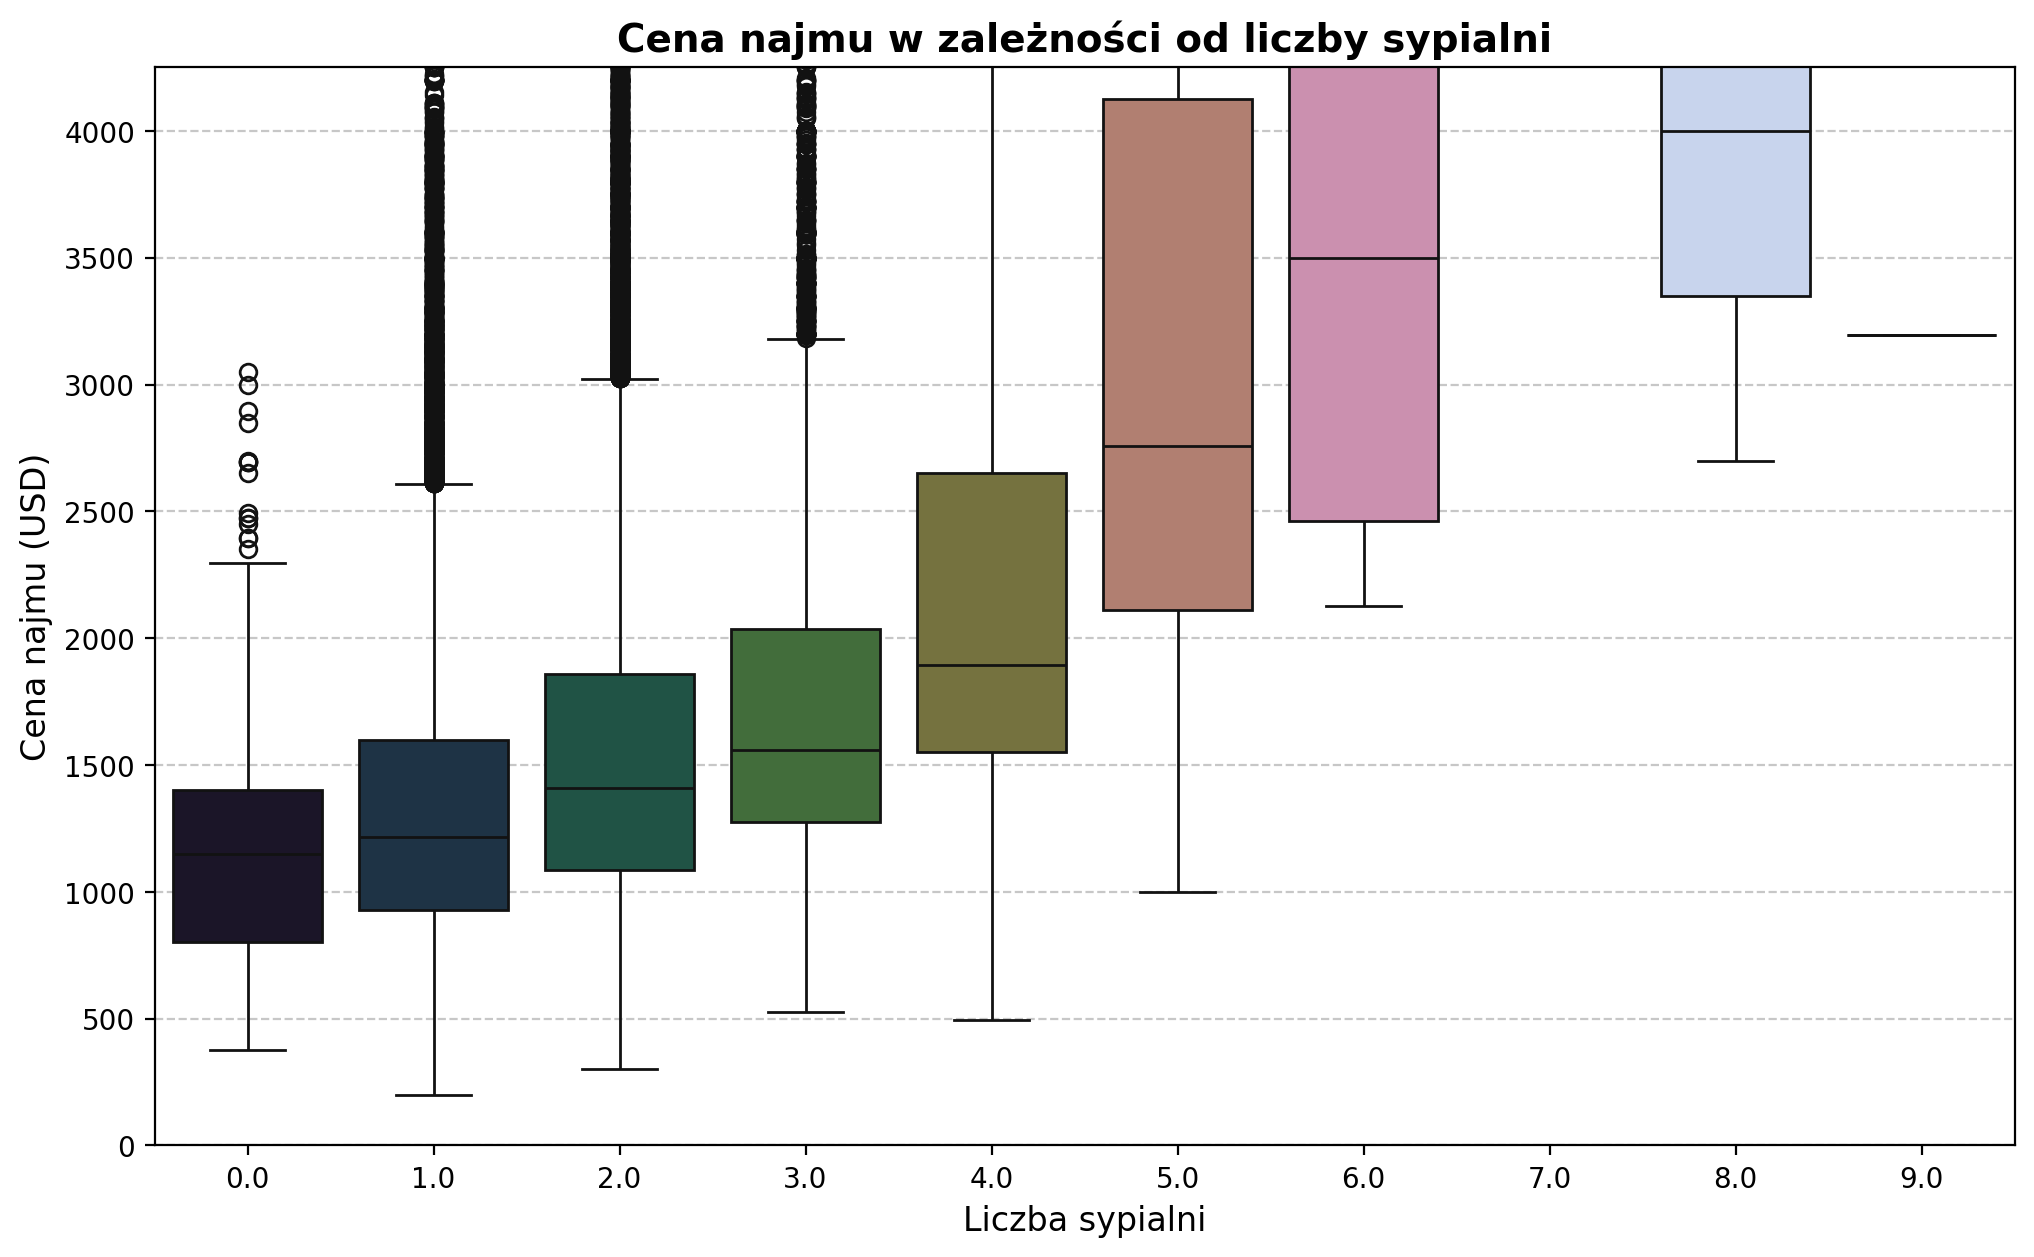

In [110]:
# Zależność ceny od liczby sypialni
plt.figure(figsize=(12, 7))
sns.boxplot(x='bedrooms', y='price', data=df, palette='cubehelix')
plt.title('Cena najmu w zależności od liczby sypialni', fontsize=14, fontweight='bold')
plt.xlabel('Liczba sypialni', fontsize=12)
plt.ylabel('Cena najmu (USD)', fontsize=12)
plt.ylim(0, df['price'].quantile(0.99)) # Ograniczenie osi Y dla lepszej czytelności
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\mhi\AppData\Local\Temp\ipykernel_30900\995924155.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='pets_allowed', y='price', data=df, palette='Paired')


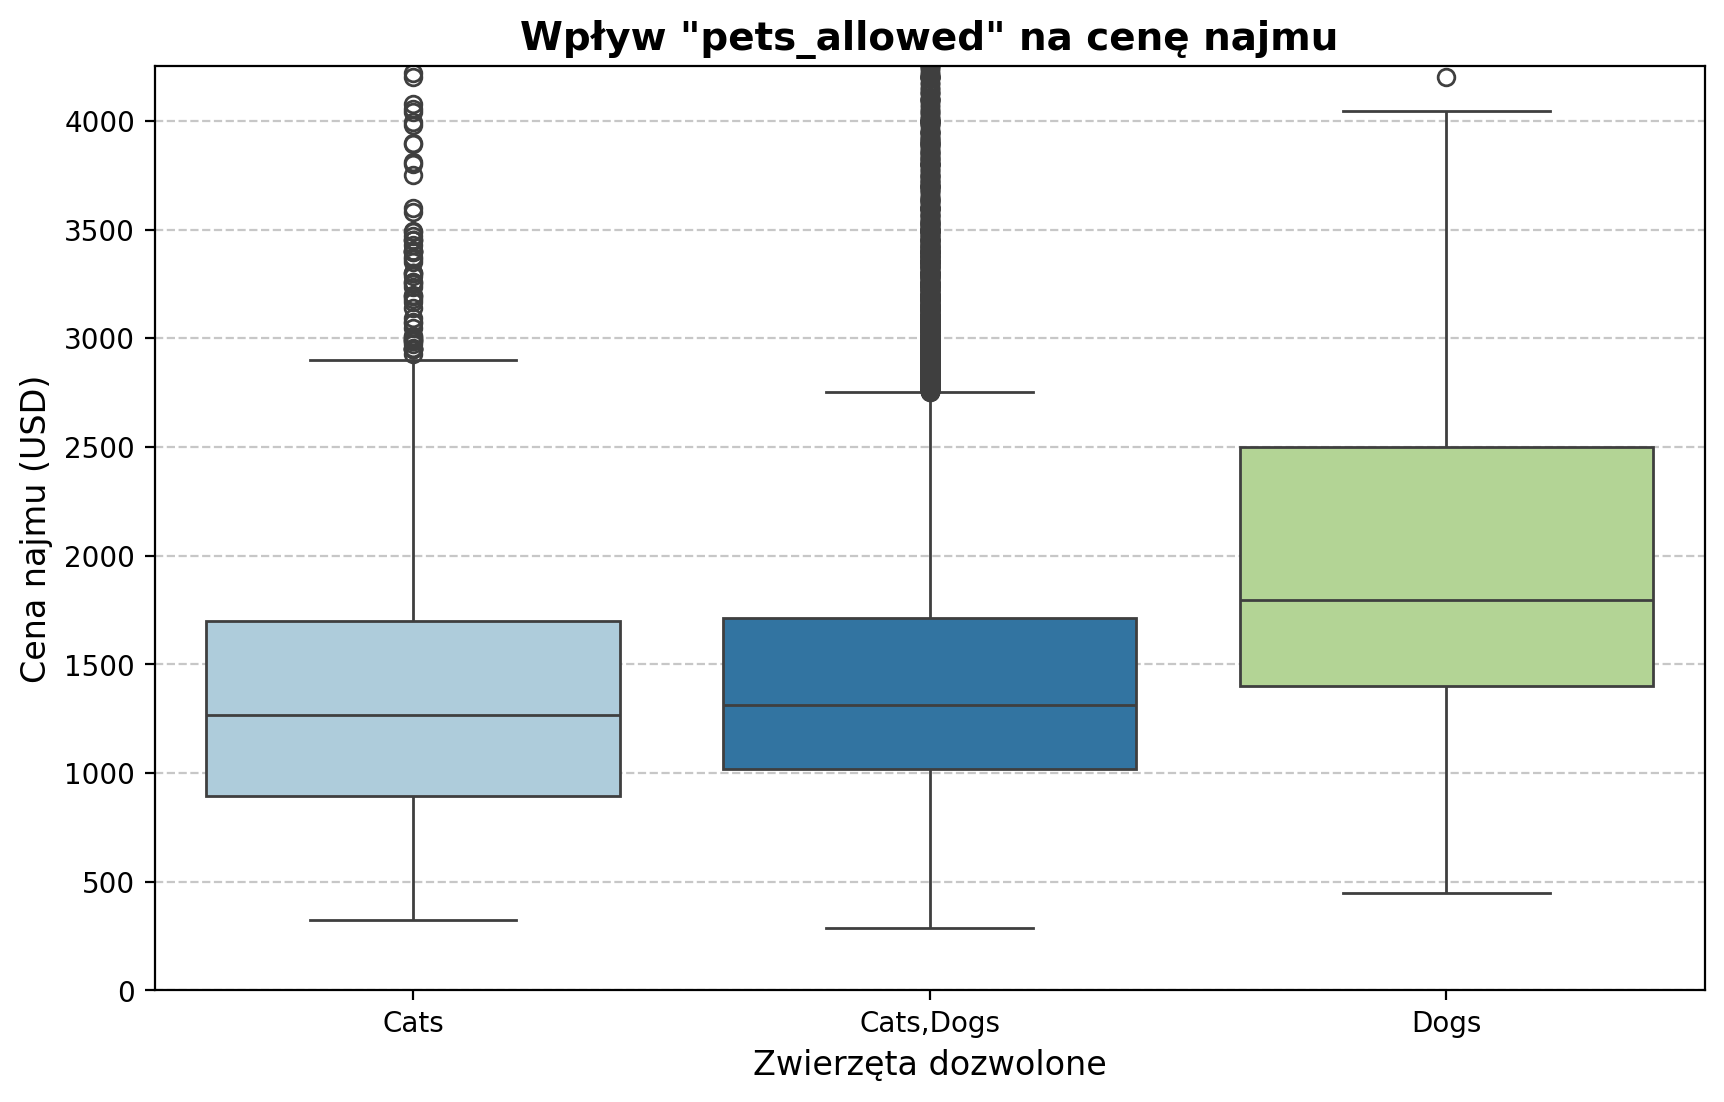

In [111]:
# Wpływ pets_allowed na cenę najmu
plt.figure(figsize=(10, 6))
sns.boxplot(x='pets_allowed', y='price', data=df, palette='Paired')
plt.title('Wpływ "pets_allowed" na cenę najmu', fontsize=14, fontweight='bold')
plt.xlabel('Zwierzęta dozwolone', fontsize=12)
plt.ylabel('Cena najmu (USD)', fontsize=12)
plt.ylim(0, df['price'].quantile(0.99)) # Ograniczenie osi Y dla lepszej czytelności
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

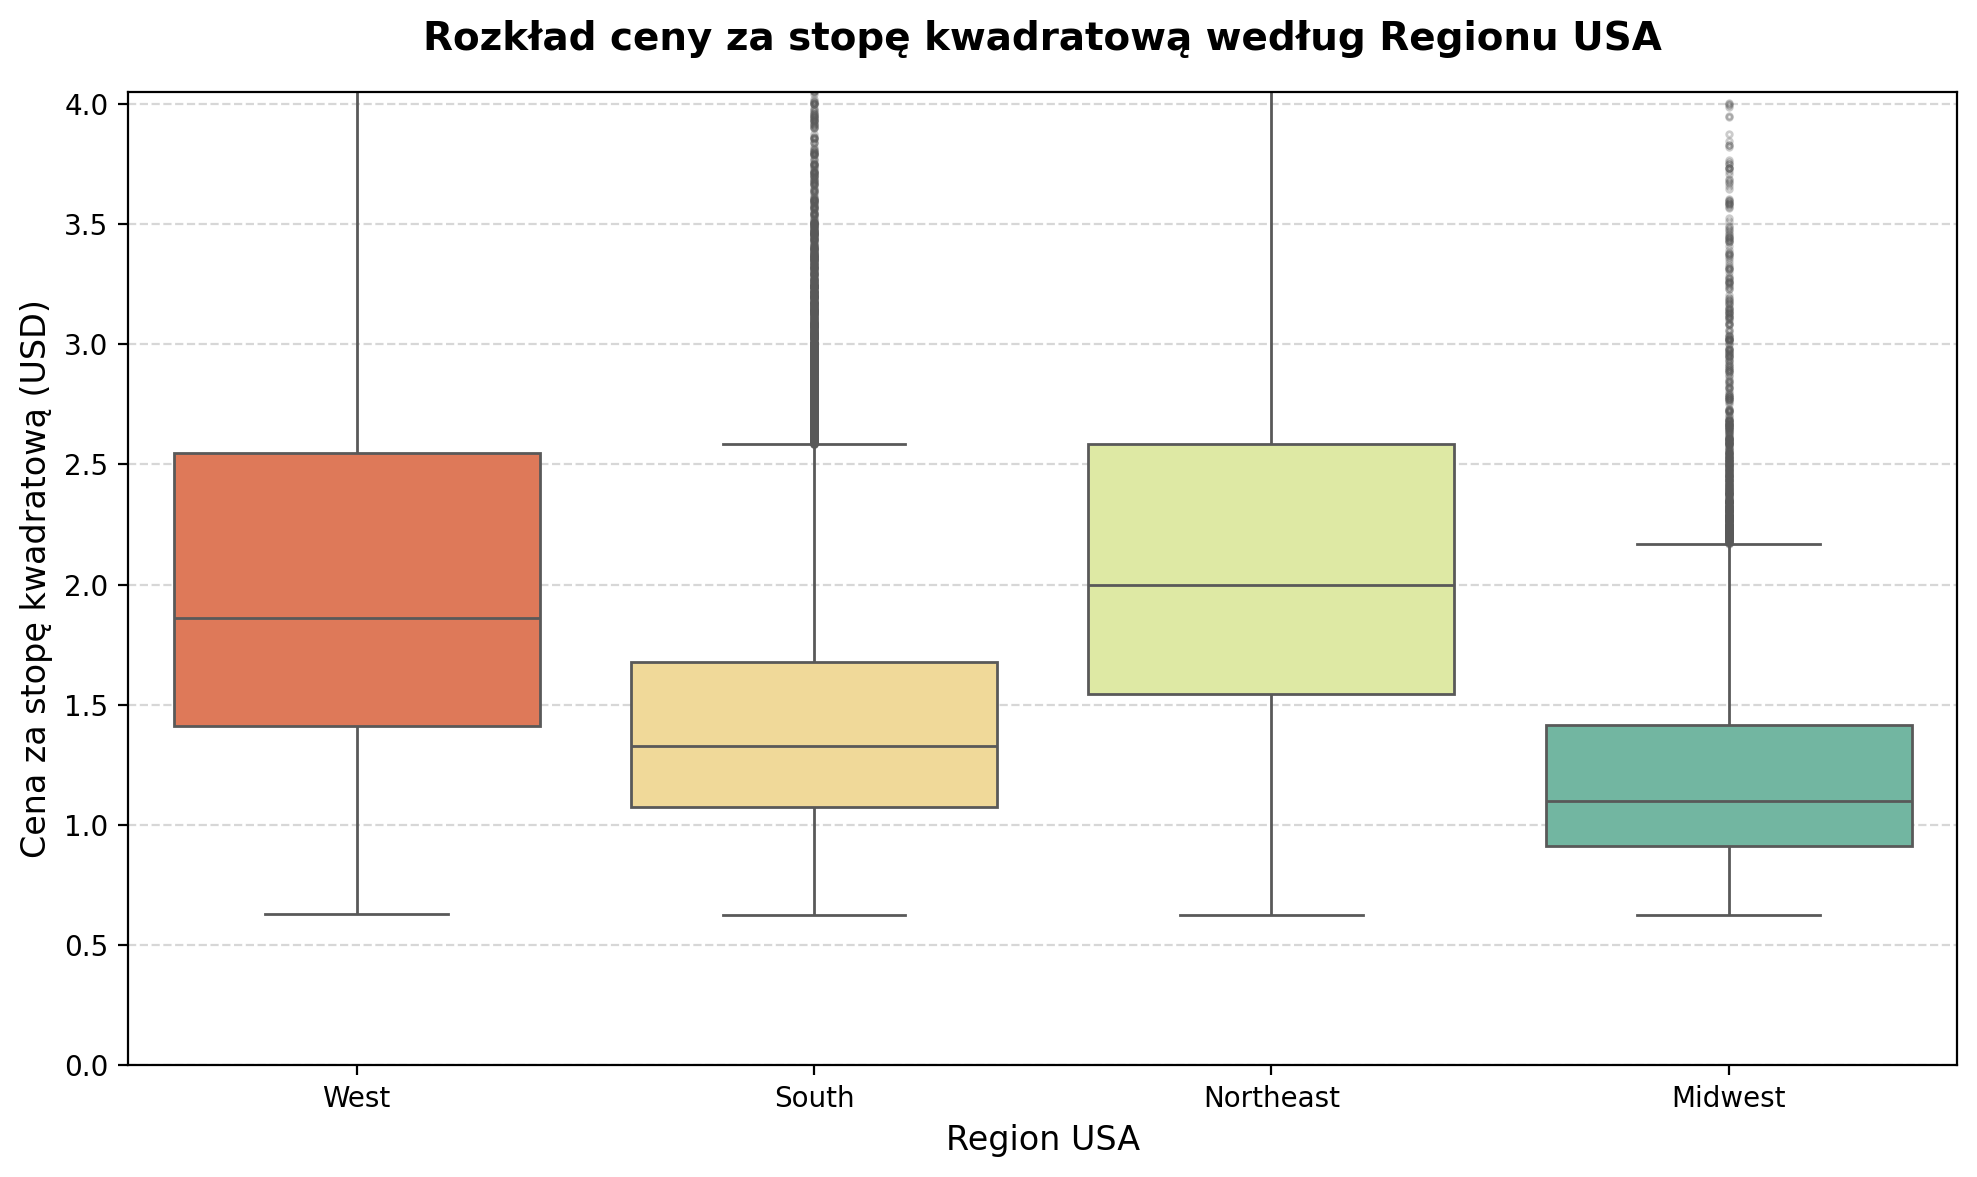

In [112]:
df_charakter = pd.read_csv('data/przypisanie_stanowUSA.csv', sep=';')

df = df.merge(
    df_charakter, 
    left_on='state',
    right_on='Skrot',     
    how='left'
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df, 
    x='Region', 
    y='price_per_sqft', 
    hue='Region', 
    palette='Spectral', 
    legend=False,
    fliersize=2,
    flierprops={"alpha": 0.3}
)

# Ograniczamy oś Y do 98. percentyla, żeby outliery nie zplotkowały wykresu
plt.ylim(0, df['price_per_sqft'].quantile(0.98)) 

plt.title('Rozkład ceny za stopę kwadratową według Regionu USA', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Region USA', fontsize=12)
plt.ylabel('Cena za stopę kwadratową (USD)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## <span style="color:deepskyblue;">4. Podsumowanie i wnioski</span>

Na podstawie przeprowadzonej analizy danych dotyczących wynajmu nieruchomości w USA można wyciągnąć następujące wnioski:

1.  **Rozkład cen i stawka jednostkowa:**
    *   Większość ofert koncentruje się w przedziale cenowym 900-1600 USD. Mediana ceny wynosi około 1355 USD, co jest bardziej reprezentatywną miarą niż średnia (1531 USD) ze względu na asymetryczny rozkład i obecność luksusowych ofert.
    *   Linia trendu wskazuje na wzrost ceny wraz z powierzchnią, jednak znaczne rozproszenie cen dla tego samego metrażu sugeruje, że czynniki takie jak lokalizacja i standard wykończenia mają kluczowe znaczenie.
    *   Mediana stawki jednostkowej (price/sqft) wynosi 1.48 USD/sq ft, a największe zagęszczenie ofert występuje w przedziale 1.00-1.50 USD/sq ft. Stawki powyżej 2.50 USD/sq ft to segment luksusowy.

2.  **Wpływ udogodnień:**
    *   Obecność **doormana** ma największy pozytywny wpływ na cenę (wzrost mediany o ~78.7% / +1064,50 USD), co jest związane z luksusowym charakterem nieruchomości oferujących tę usługę. Portier występuje rzadko (tylko 204 oferty) i jest cechą rozpoznawczą najdroższych wieżowców w ścisłych centrach metropolii.
    *   **Windy (Elevator)** również znacząco podnoszą cenę (wzrost mediany o ~25.3% / +340,50 USD), wyraźnie oddzielając nowsze, wyższe budynki od starszej, niskiej zabudowy.
    *   **Drewniane podłogi (Wood Floors)** i **widok (View)** generują zbliżoną premię cenową (wzrost mediany o ~14-15% / ok. 190–197 USD do mediany).
    *   Udogodnienia masowe, takie jak siłownia (Gym), osiedle zamknięte (Gated) czy parking (Parking), mają stosunkowo niewielki wpływ na cenę (wzrost mediany o 1.5-3.6% / 20–48 USD), ponieważ występują w dziesiątkach tysięcy ofert i stanowią już standard rynkowy, a nie luksus.

3.  **Analiza geograficzna (Regiony i Stany):**
    *   Rozkład cen najmu różni się znacząco w zależności od regionu USA, z widocznymi różnicami między regionami wschodnimi i zachodnimi.
    *   Wśród małych nieruchomości (do 300 stóp kwadratowych), regiony Northeast oraz Midwest mają przewagę ofert z przedziału 250 - 300 stóp kwadratowych, podczas gdy w pozostałych regionach większość tego typu ofert dotyczy przedziału 200 - 250 stóp kwadratowych.
    *   W przypadku nieruchomości średnich i dużych, tendencja do koncentracji ofert w określonych przedziałach powierzchni utrzymuje się, ale różnice między regionami są mniej wyraźne.
    *   Charakter stanu (rolniczy, przemysłowy, turystyczny) ma wpływ na rozkład cen, ale nie jest to jedyny czynnik. Regionalne i lokalne uwarunkowania odgrywają kluczową rolę.

4.  **Liczba sypialni i łazienek:**
    *   Wzrost liczby sypialni i łazienek koreluje z wyższą ceną najmu, co jest naturalne dla większych nieruchomości oferujących więcej przestrzeni i komfortu.

5.  **Pets Allowed:**
    *   Dostępność opcji 'pets allowed' ma wpływ na medianę ceny za stopę kwadratową, co sugeruje, że właściciele nieruchomości dostosowują ceny w zależności od polityki wobec zwierząt. W niektórych kategoriach 'pets allowed' (np. 'Cats,Dogs') mediana ceny może być wyższa, co może wynikać z większego zapotrzebowania na takie nieruchomości lub z kompensacji za potencjalne zużycie.

Ogólnie rzecz biorąc, rynek wynajmu nieruchomości w USA jest zróżnicowany, a cena zależy od wielu czynników, w tym lokalizacji, udogodnień, wielkości i polityki właścicieli.